# DAY 21 — Baseline vs Tuned Results and Project-Specific Study
## Underwater Garbage Detection (TrashCAN Dataset V1, YOLOv8n)

**Daily output:** presentation-ready comparison — baseline vs tuned results, the project-specific (robustness) study, representative successes and failures, and a discussion of remaining weaknesses and unusual errors.

### What this notebook presents
1. **Baseline vs tuned** — overall metrics, class-wise metrics, training curves, model size and speed.
2. **Held-out test result** — the test split is evaluated **once** (results are cached so it cannot be re-run by accident).
3. **Project-specific study** — the Day 20 robustness / ablation results (low visibility, clutter, occlusion, small objects).
4. **Representative successes and failures** — side-by-side galleries: ground truth | baseline | tuned.
5. **Remaining weaknesses and unusual errors** — error types, confusions, confident mistakes, possible label problems.
6. **Conclusion** — generated from the measured numbers; no value is typed in by hand.

No training happens here: both models are loaded from their saved `best.pt`.

## 21.1 Setup

In [1]:
# ============================================================
# 1. SETUP — packages, imports, Google Drive
# ============================================================
import sys, subprocess, importlib.util

if importlib.util.find_spec("ultralytics") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "ultralytics"])

import os, json, time, shutil, zlib, random, warnings, hashlib, zipfile
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import yaml
import cv2
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import torch
from ultralytics import YOLO
import ultralytics

warnings.filterwarnings("ignore")

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except Exception as e:
    print("Drive mount skipped:", e)

print("Ultralytics:", ultralytics.__version__)
print("PyTorch    :", torch.__version__)
print("CUDA       :", torch.cuda.is_available(),
      "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "no GPU")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Mounted at /content/drive
Ultralytics: 8.4.171
PyTorch    : 2.11.0+cu130
CUDA       : True | Tesla T4


## 21.2 Configuration

In [2]:
# ============================================================
# 2. CONFIGURATION — edit only this cell
# ============================================================
PROJECT_DIR = Path("/content/drive/MyDrive/INTERNSHIPWORK/yolo_runs")
SOURCE_ZIP  = Path("/content/drive/MyDrive/INTERNSHIPWORK/dataset.zip")   # used only if Dataset V1 must be rebuilt
SOURCE_ROOT = Path("/content/TrashCAN")
V1_ROOT     = Path("/content/TrashCAN_YOLO_Dataset_V1")
OUT_DIR     = PROJECT_DIR / "day21_outputs"
DAY20_DIR   = PROJECT_DIR / "day20_outputs"
WORK_DIR    = Path("/content/day21_work")
VAL_TMP     = WORK_DIR / "val_runs"
SEED = 42

STRICT_DATASET_CHECK = True
FINAL_TEST_EVALUATION = True     # one-time held-out evaluation; cached after the first run
FORCE_RERUN_TEST = False         # leave False: re-running the test set after looking at it defeats its purpose
CONF_EVAL = 0.25                 # confidence threshold for object-level analysis and galleries
UNUSUAL_CONF = 0.70              # a mistake at or above this confidence is "confident"
N_GALLERY = 4                    # image rows per gallery
MEANINGFUL_DELTA = 0.01          # mAP50-95 difference treated as a real change on this dataset
N_BOOT = 2000
DAY19_MIN_EPOCHS = 10
MODEL_OVERRIDES = {}             # e.g. {"baseline": ".../day15_yolov8n_baseline-5", "tuned": ".../day19_xxx"}
HAS_GPU = torch.cuda.is_available()
FPS_MAX_IMAGES = None if HAS_GPU else 200

random.seed(SEED); np.random.seed(SEED)
for d in [OUT_DIR, OUT_DIR / "figures", WORK_DIR, VAL_TMP]:
    d.mkdir(parents=True, exist_ok=True)
assert PROJECT_DIR.exists(), f"Run folder not found: {PROJECT_DIR}"
print("Outputs ->", OUT_DIR)

Outputs -> /content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/day21_outputs


## 21.3 Helper library

In [3]:
# ============================================================
# CORE HELPERS — labels, IoU, matching, size buckets, prediction records, drawing
# ============================================================
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
SMALL_AREA = 0.01          # Day 13 definition: box area <= 1% of image area
VERY_SMALL_AREA = 0.005    # Day 13 definition: box area <= 0.5% of image area
MEDIUM_AREA = 0.05         # medium: 1% < area <= 5%; large: > 5%

OUTCOME_COLORS = {
    "TP": "lime", "wrong_class": "orange", "localization": "yellow",
    "duplicate": "magenta", "background": "red",
}

def list_images(folder):
    return sorted(p for p in Path(folder).iterdir() if p.suffix.lower() in IMG_EXTS)

def read_yolo_label(path):
    path = Path(path)
    if not path.exists():
        return np.zeros((0, 5), dtype=np.float32)
    rows = []
    for line in path.read_text(encoding="utf-8").splitlines():
        parts = line.split()
        if len(parts) == 5:
            rows.append([float(x) for x in parts])
    return np.array(rows, dtype=np.float32).reshape(-1, 5)

def write_yolo_label(path, lbl):
    lines = [f"{int(r[0])} {r[1]:.6f} {r[2]:.6f} {r[3]:.6f} {r[4]:.6f}" for r in lbl]
    Path(path).write_text("\n".join(lines), encoding="utf-8")

def yolo_to_xyxy(lbl, W, H):
    if len(lbl) == 0:
        return np.zeros((0, 4), np.float32)
    xc, yc, w, h = lbl[:, 1] * W, lbl[:, 2] * H, lbl[:, 3] * W, lbl[:, 4] * H
    return np.stack([xc - w / 2, yc - h / 2, xc + w / 2, yc + h / 2], 1).astype(np.float32)

def iou_matrix(a, b):
    """a: (N,4) xyxy, b: (M,4) xyxy -> (N,M) IoU."""
    a = np.asarray(a, np.float32).reshape(-1, 4)
    b = np.asarray(b, np.float32).reshape(-1, 4)
    if len(a) == 0 or len(b) == 0:
        return np.zeros((len(a), len(b)), np.float32)
    ix1 = np.maximum(a[:, None, 0], b[None, :, 0]); iy1 = np.maximum(a[:, None, 1], b[None, :, 1])
    ix2 = np.minimum(a[:, None, 2], b[None, :, 2]); iy2 = np.minimum(a[:, None, 3], b[None, :, 3])
    inter = np.clip(ix2 - ix1, 0, None) * np.clip(iy2 - iy1, 0, None)
    area_a = (a[:, 2] - a[:, 0]) * (a[:, 3] - a[:, 1])
    area_b = (b[:, 2] - b[:, 0]) * (b[:, 3] - b[:, 1])
    union = area_a[:, None] + area_b[None, :] - inter
    return inter / np.maximum(union, 1e-9)

def size_bucket(area_ratio):
    if area_ratio <= SMALL_AREA:
        return "small"
    if area_ratio <= MEDIUM_AREA:
        return "medium"
    return "large"

def match_image(gt_cls, gt_box, pr_cls, pr_box, pr_conf, iou_tp=0.5, iou_loc=0.1):
    """
    Greedy confidence-ordered matching of ONE image.
    GT outcomes : correct | wrong_class | poor_localization | missed
    Pred kinds  : TP | wrong_class | localization | duplicate | background
    """
    ng, npred = len(gt_cls), len(pr_cls)
    gt_out = [dict(outcome="missed", pred=-1, iou=0.0, conf=0.0) for _ in range(ng)]
    pr_out = [None] * npred
    if npred == 0:
        return gt_out, pr_out
    ious = iou_matrix(pr_box, gt_box) if ng else np.zeros((npred, 0), np.float32)
    used = np.zeros(ng, bool)
    for pi in np.argsort(-np.asarray(pr_conf)):
        row = ious[pi]
        pc = int(pr_cls[pi])
        # 1) correct detection: same class, unused GT, IoU >= iou_tp
        cand = [(row[g], g) for g in range(ng) if (not used[g]) and int(gt_cls[g]) == pc and row[g] >= iou_tp]
        if cand:
            v, g = max(cand)
            used[g] = True
            gt_out[g] = dict(outcome="correct", pred=pc, iou=float(v), conf=float(pr_conf[pi]))
            pr_out[pi] = dict(kind="TP", gt=int(g), iou=float(v))
            continue
        # 2) wrong class: different class, unused GT, IoU >= iou_tp
        cand = [(row[g], g) for g in range(ng) if (not used[g]) and int(gt_cls[g]) != pc and row[g] >= iou_tp]
        if cand:
            v, g = max(cand)
            used[g] = True
            gt_out[g] = dict(outcome="wrong_class", pred=pc, iou=float(v), conf=float(pr_conf[pi]))
            pr_out[pi] = dict(kind="wrong_class", gt=int(g), iou=float(v))
            continue
        # 3) poor localization: same class, unused GT, iou_loc <= IoU < iou_tp
        cand = [(row[g], g) for g in range(ng) if (not used[g]) and int(gt_cls[g]) == pc and iou_loc <= row[g] < iou_tp]
        if cand:
            v, g = max(cand)
            used[g] = True
            gt_out[g] = dict(outcome="poor_localization", pred=pc, iou=float(v), conf=float(pr_conf[pi]))
            pr_out[pi] = dict(kind="localization", gt=int(g), iou=float(v))
            continue
        # 4) duplicate: overlaps an already-matched GT of the same class
        dup = [g for g in range(ng) if used[g] and int(gt_cls[g]) == pc and row[g] >= iou_tp]
        if dup:
            pr_out[pi] = dict(kind="duplicate", gt=int(dup[0]), iou=float(row[dup[0]]))
        else:
            pr_out[pi] = dict(kind="background", gt=-1, iou=float(row.max()) if ng else 0.0)
    return gt_out, pr_out

def predict_records(model, image_paths, label_dir, imgsz, conf=0.25, iou=0.7, batch=16):
    """Run the detector once per image and attach GT + match outcomes."""
    records = []
    paths = [str(p) for p in image_paths]
    stream = model.predict(source=paths, imgsz=imgsz, conf=conf, iou=iou,
                           stream=True, verbose=False, batch=batch)
    for res in stream:
        H, W = res.orig_shape[:2]
        stem = Path(res.path).stem
        lbl = read_yolo_label(Path(label_dir) / f"{stem}.txt")
        gt_cls = lbl[:, 0].astype(int) if len(lbl) else np.zeros(0, int)
        gt_box = yolo_to_xyxy(lbl, W, H)
        gt_area = (lbl[:, 3] * lbl[:, 4]) if len(lbl) else np.zeros(0, np.float32)
        if res.boxes is not None and len(res.boxes):
            pr_box = res.boxes.xyxy.cpu().numpy().astype(np.float32)
            pr_cls = res.boxes.cls.cpu().numpy().astype(int)
            pr_conf = res.boxes.conf.cpu().numpy().astype(np.float32)
        else:
            pr_box = np.zeros((0, 4), np.float32); pr_cls = np.zeros(0, int); pr_conf = np.zeros(0, np.float32)
        gt_out, pr_out = match_image(gt_cls, gt_box, pr_cls, pr_box, pr_conf)
        records.append(dict(path=str(res.path), image=Path(res.path).name, W=int(W), H=int(H),
                            gt_cls=gt_cls, gt_box=gt_box, gt_area=gt_area, gt_out=gt_out,
                            pr_cls=pr_cls, pr_box=pr_box, pr_conf=pr_conf, pr_out=pr_out))
    return records

def records_to_object_table(records, class_names, model_label):
    """One row per GT object."""
    rows = []
    for r in records:
        for i in range(len(r["gt_cls"])):
            o = r["gt_out"][i]
            rows.append(dict(model=model_label, image=r["image"], gt_index=i,
                             gt_class=class_names[int(r["gt_cls"][i])], area=float(r["gt_area"][i]),
                             size=size_bucket(float(r["gt_area"][i])),
                             very_small=bool(r["gt_area"][i] <= VERY_SMALL_AREA),
                             outcome=o["outcome"], pred_class=(class_names[o["pred"]] if o["pred"] >= 0 else None),
                             iou=o["iou"], conf=o["conf"]))
    return pd.DataFrame(rows)

def records_to_fp_table(records, class_names, model_label):
    """One row per prediction that is not a true positive."""
    rows = []
    for r in records:
        for j in range(len(r["pr_cls"])):
            k = r["pr_out"][j]["kind"]
            if k == "TP":
                continue
            x1, y1, x2, y2 = r["pr_box"][j]
            rows.append(dict(model=model_label, image=r["image"], kind=k,
                             pred_class=class_names[int(r["pr_cls"][j])], conf=float(r["pr_conf"][j]),
                             box_area=float((x2 - x1) * (y2 - y1) / (r["W"] * r["H"])),
                             iou_best_gt=r["pr_out"][j]["iou"], gt_objects_in_image=len(r["gt_cls"])))
    return pd.DataFrame(rows)

def image_error_count(rec):
    n_gt_bad = sum(o["outcome"] != "correct" for o in rec["gt_out"])
    n_fp = sum(p["kind"] in ("background", "duplicate") for p in rec["pr_out"])
    return int(n_gt_bad + n_fp)

def draw_panel(ax, img_rgb, rec, class_names, mode, title=""):
    """mode='gt' draws ground truth; mode='pred' draws predictions coloured by outcome
    (missed GT objects are shown dashed cyan so failures are visible)."""
    ax.imshow(img_rgb); ax.axis("off")
    def _box(b, color, text, ls="-", lw=2):
        ax.add_patch(plt.Rectangle((b[0], b[1]), b[2] - b[0], b[3] - b[1], fill=False,
                                   edgecolor=color, linewidth=lw, linestyle=ls))
        ax.text(b[0], max(0, b[1] - 3), text, color="black", fontsize=7,
                bbox=dict(facecolor=color, alpha=0.75, pad=0.8, edgecolor="none"))
    if mode == "gt":
        for c, b in zip(rec["gt_cls"], rec["gt_box"]):
            _box(b, "cyan", class_names[int(c)])
    else:
        for i, o in enumerate(rec["gt_out"]):
            if o["outcome"] in ("missed", "poor_localization", "wrong_class"):
                _box(rec["gt_box"][i], "cyan", "GT:" + class_names[int(rec["gt_cls"][i])], ls="--", lw=1.5)
        for j in range(len(rec["pr_cls"])):
            k = rec["pr_out"][j]["kind"]
            _box(rec["pr_box"][j], OUTCOME_COLORS[k],
                 f"{class_names[int(rec['pr_cls'][j])]} {rec['pr_conf'][j]:.2f}")
    ax.set_title(title, fontsize=8)

def gallery(rec_pairs, images_dir, class_names, model_labels, title, max_rows=4, save_path=None):
    """rec_pairs: list of tuples (rec_model_A, rec_model_B, caption). Columns: GT | model A | model B."""
    rec_pairs = rec_pairs[:max_rows]
    if not rec_pairs:
        print(f"[{title}] no matching images found.")
        return None
    fig, axes = plt.subplots(len(rec_pairs), 3, figsize=(15, 3.6 * len(rec_pairs)), squeeze=False)
    for row, (ra, rb, cap) in enumerate(rec_pairs):
        img = cv2.cvtColor(cv2.imread(str(Path(images_dir) / ra["image"])), cv2.COLOR_BGR2RGB)
        draw_panel(axes[row][0], img, ra, class_names, "gt", f"Ground truth — {cap}")
        draw_panel(axes[row][1], img, ra, class_names, "pred", f"{model_labels[0]}")
        draw_panel(axes[row][2], img, rb, class_names, "pred", f"{model_labels[1]}")
    fig.suptitle(title, fontsize=12)
    fig.text(0.5, 0.005, "Prediction colours: lime=correct, orange=wrong class, yellow=poor localization, "
             "magenta=duplicate, red=false positive; dashed cyan=missed/failed ground truth",
             ha="center", fontsize=8)
    fig.tight_layout(rect=(0, 0.02, 1, 0.97))
    if save_path:
        fig.savefig(save_path, dpi=130, bbox_inches="tight")
    plt.show()
    return fig


def save_fig(fig, name):
    fig.savefig(OUT_DIR / 'figures' / name, dpi=140, bbox_inches='tight')

## 21.4 Dataset V1 restore and integrity check

In [4]:
# ============================================================
# 3. RESTORE + VERIFY DATASET V1 (the exact split used by Days 15-17)
# ============================================================
# Day 11 split: original train pool -> 80% train / 20% test (GroupShuffleSplit, seed 42);
# original val pool -> kept as validation.  Expected sizes are checked below because a
# different split (for example 5768/722/722) would put images that the Day 15-17 models
# trained on into validation and inflate every metric.

EXPECTED_SPLIT = {
    "images":     {"train": 4806, "val": 1204, "test": 1202},
    "label_rows": {"train": 3947, "val": 1281, "test": 986},
}

def count_split(root):
    root = Path(root)
    out = {"images": {}, "label_rows": {}}
    for s in ["train", "val", "test"]:
        img_dir, lab_dir = root / "images" / s, root / "labels" / s
        out["images"][s] = len(list_images(img_dir)) if img_dir.exists() else 0
        rows = 0
        if lab_dir.exists():
            for f in lab_dir.glob("*.txt"):
                rows += sum(1 for ln in f.read_text(encoding="utf-8").splitlines() if ln.strip())
        out["label_rows"][s] = rows
    return out

def rebuild_dataset_v1():
    from sklearn.model_selection import GroupShuffleSplit
    if not SOURCE_ZIP.exists():
        raise FileNotFoundError(f"Source dataset ZIP not found: {SOURCE_ZIP}")
    if not SOURCE_ROOT.exists():
        with zipfile.ZipFile(SOURCE_ZIP, "r") as z:
            z.extractall(SOURCE_ROOT)
    material = next((p for p in [SOURCE_ROOT / "dataset" / "material_version",
                                 SOURCE_ROOT / "material_version"] if p.exists()), None)
    if material is None:
        hits = list(SOURCE_ROOT.rglob("material_version"))
        material = hits[0] if hits else None
    if material is None:
        raise FileNotFoundError("material_version folder not found inside the dataset ZIP.")

    pools = {}
    for pool in ["train", "val"]:
        with open(material / f"instances_{pool}_trashcan.json", "r") as f:
            pools[pool] = json.load(f)
    categories = pools["train"]["categories"]
    garbage = sorted([c for c in categories if c["name"].startswith("trash_")], key=lambda c: c["name"])
    yolo_map = {c["id"]: i for i, c in enumerate(garbage)}
    names = [c["name"] for c in garbage]

    def sha256_file(path):
        h = hashlib.sha256()
        with open(path, "rb") as f:
            for chunk in iter(lambda: f.read(1024 * 1024), b""):
                h.update(chunk)
        return h.hexdigest()

    records = []
    anns = defaultdict(list)
    for pool in ["train", "val"]:
        for a in pools[pool]["annotations"]:
            anns[(pool, int(a["image_id"]))].append(a)
        for img in pools[pool]["images"]:
            fn = os.path.basename(img["file_name"])
            path = material / pool / fn
            records.append(dict(pool=pool, filename=fn, path=str(path), w=int(img["width"]),
                                h=int(img["height"]), image_id=int(img["id"]), sha=sha256_file(path)))
    df = pd.DataFrame(records)
    src_train = df[df.pool == "train"].copy()
    tr_idx, te_idx = next(GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
                          .split(src_train, groups=src_train["sha"]))
    split = pd.concat([src_train.iloc[tr_idx].assign(split="train"),
                       df[df.pool == "val"].assign(split="val"),
                       src_train.iloc[te_idx].assign(split="test")], ignore_index=True)

    if V1_ROOT.exists():
        shutil.rmtree(V1_ROOT)
    for s in ["train", "val", "test"]:
        (V1_ROOT / "images" / s).mkdir(parents=True, exist_ok=True)
        (V1_ROOT / "labels" / s).mkdir(parents=True, exist_ok=True)

    for _, row in tqdm(split.iterrows(), total=len(split), desc="Rebuilding Dataset V1"):
        shutil.copy2(row["path"], V1_ROOT / "images" / row["split"] / row["filename"])
        lines = []
        for a in anns[(row["pool"], row["image_id"])]:
            if int(a["category_id"]) not in yolo_map:
                continue
            x, y, w, h = [float(v) for v in a["bbox"]]
            x1, y1 = max(0.0, min(x, row["w"])), max(0.0, min(y, row["h"]))
            x2, y2 = max(0.0, min(x + w, row["w"])), max(0.0, min(y + h, row["h"]))
            if x2 - x1 <= 0 or y2 - y1 <= 0:
                continue
            vals = [(x1 + x2) / 2 / row["w"], (y1 + y2) / 2 / row["h"], (x2 - x1) / row["w"], (y2 - y1) / row["h"]]
            vals = [min(1.0, max(0.0, v)) for v in vals]
            lines.append(str(yolo_map[int(a["category_id"])]) + " " + " ".join(f"{v:.6f}" for v in vals))
        (V1_ROOT / "labels" / row["split"] / f"{Path(row['filename']).stem}.txt").write_text("\n".join(lines), encoding="utf-8")

    with open(V1_ROOT / "data.yaml", "w", encoding="utf-8") as f:
        yaml.safe_dump({"path": str(V1_ROOT), "train": "images/train", "val": "images/val",
                        "test": "images/test", "names": names}, f, sort_keys=False)

def split_matches_expected(counts):
    return counts == EXPECTED_SPLIT

if (V1_ROOT / "data.yaml").exists():
    DATASET_COUNTS = count_split(V1_ROOT)
    if not split_matches_expected(DATASET_COUNTS):
        print("Existing Dataset V1 does NOT match the Day 15-17 split:", DATASET_COUNTS)
        print("Rebuilding with the Day 11 rule (no model training involved)...")
        rebuild_dataset_v1()
else:
    print("Dataset V1 missing in this runtime. Rebuilding with the Day 11 rule (no training)...")
    rebuild_dataset_v1()

DATASET_COUNTS = count_split(V1_ROOT)
DATASET_OK = split_matches_expected(DATASET_COUNTS)
print("Images     :", DATASET_COUNTS["images"])
print("Label rows :", DATASET_COUNTS["label_rows"])
print("Matches Day 11 / Day 15-17 split:", "PASS" if DATASET_OK else "FAIL")
if STRICT_DATASET_CHECK and not DATASET_OK:
    raise AssertionError("Dataset V1 differs from the split used to train the Day 15-17 models. "
                         f"Expected {EXPECTED_SPLIT}, found {DATASET_COUNTS}.")

with open(V1_ROOT / "data.yaml", "r", encoding="utf-8") as f:
    _cfg = yaml.safe_load(f)
CLASS_NAMES = list(_cfg["names"].values()) if isinstance(_cfg["names"], dict) else list(_cfg["names"])
DATA_YAML = V1_ROOT / "data.yaml"
VAL_IMG_DIR, VAL_LBL_DIR = V1_ROOT / "images" / "val", V1_ROOT / "labels" / "val"
TEST_IMG_DIR, TEST_LBL_DIR = V1_ROOT / "images" / "test", V1_ROOT / "labels" / "test"
print("Classes    :", CLASS_NAMES)

Dataset V1 missing in this runtime. Rebuilding with the Day 11 rule (no training)...


Rebuilding Dataset V1:   0%|          | 0/7212 [00:00<?, ?it/s]

Images     : {'train': 4806, 'val': 1204, 'test': 1202}
Label rows : {'train': 3947, 'val': 1281, 'test': 986}
Matches Day 11 / Day 15-17 split: PASS
Classes    : ['trash_etc', 'trash_fabric', 'trash_fishing_gear', 'trash_metal', 'trash_paper', 'trash_plastic', 'trash_rubber', 'trash_wood']


## 21.5 Select the two models being compared
* **Baseline** = the Day 15 pretrained YOLOv8n run (longest completed run; ties broken by best validation mAP50-95).
* **Tuned** = the **Day 19 best validated configuration** if Day 19 runs exist on Drive, otherwise the Day 17 tuned run.

The runs actually used are printed, so they can be pinned with `MODEL_OVERRIDES` if a different run was intended.

In [5]:
# ============================================================
# RUN DISCOVERY HELPERS — reads saved results.csv / args.yaml / best.pt (no retraining)
# ============================================================
def read_results_csv(csv_path):
    df = pd.read_csv(csv_path)
    df.columns = [c.strip() for c in df.columns]
    return df

def completed_runs(prefix, min_epochs=1):
    rows = []
    for d in sorted(PROJECT_DIR.glob(prefix + "*")):
        csv_f, best = d / "results.csv", d / "weights" / "best.pt"
        if not (csv_f.exists() and best.exists()):
            continue
        try:
            df = read_results_csv(csv_f)
            if df.empty or "metrics/mAP50-95(B)" not in df.columns:
                continue
            ep = int(df["epoch"].max())
            if ep < min_epochs:
                continue
            rows.append(dict(run=d.name, run_dir=d, epochs=ep, best_map50_95=float(df["metrics/mAP50-95(B)"].max()),
                             best_map50=float(df["metrics/mAP50(B)"].max()), best_pt=best, csv=csv_f))
        except Exception as e:
            print("Skipping", d.name, "->", e)
    # longest completed run first; ties -> higher best validation mAP50-95
    return sorted(rows, key=lambda r: (r["epochs"], r["best_map50_95"]), reverse=True)

def load_args(run_dir):
    f = Path(run_dir) / "args.yaml"
    return yaml.safe_load(f.read_text()) if f.exists() else {}

def show_candidates(title, rows):
    print(f"\n{title}: {len(rows)} completed run(s)")
    if rows:
        display(pd.DataFrame([{k: (str(v) if k in ("run_dir", "best_pt", "csv") else v) for k, v in r.items()
                               if k in ("run", "epochs", "best_map50", "best_map50_95")} for r in rows]).round(5).head(8))

def load_model_entry(key, label, run_row):
    args = load_args(run_row["run_dir"])
    imgsz = int(args.get("imgsz", 640))
    return dict(key=key, label=label, run=run_row["run"], run_dir=run_row["run_dir"], best_pt=run_row["best_pt"],
                csv=run_row["csv"], epochs=run_row["epochs"], args=args, imgsz=imgsz, model=YOLO(str(run_row["best_pt"])))

def pinned_row(run_dir):
    run_dir = Path(run_dir)
    df = read_results_csv(run_dir / "results.csv")
    return dict(run=run_dir.name, run_dir=run_dir, epochs=int(df["epoch"].max()),
                best_map50_95=float(df["metrics/mAP50-95(B)"].max()), best_map50=float(df["metrics/mAP50(B)"].max()),
                best_pt=run_dir / "weights" / "best.pt", csv=run_dir / "results.csv")

def measure_fps(model, source_dir, imgsz, warmup_images=20, max_images=None):
    paths = [str(p) for p in list_images(source_dir)]
    if max_images:
        paths = paths[:max_images]
    _ = list(model.predict(source=paths[:warmup_images], imgsz=imgsz, stream=True, verbose=False))
    t0 = time.perf_counter(); n = 0
    for _r in model.predict(source=paths, imgsz=imgsz, stream=True, verbose=False, batch=1):
        n += 1
    dt = time.perf_counter() - t0
    return dict(images=n, ms_per_image=dt / max(n, 1) * 1000, fps=n / dt if dt > 0 else float("nan"))

def metrics_by_class(m, n_classes):
    """Map Ultralytics per-class arrays onto all class ids (robust to classes absent from the split)."""
    out = {k: np.full(n_classes, np.nan) for k in ["P", "R", "mAP50", "mAP50_95"]}
    for pos, cid in enumerate(np.asarray(m.box.ap_class_index).astype(int)):
        out["P"][cid] = m.box.p[pos]; out["R"][cid] = m.box.r[pos]
        out["mAP50"][cid] = m.box.ap50[pos]; out["mAP50_95"][cid] = m.box.ap[pos]
    return out

def run_val(model, data_yaml, imgsz, name, split="val"):
    m = model.val(data=str(data_yaml), imgsz=imgsz, batch=16, plots=False, verbose=False,
                  project=str(VAL_TMP), name=name, exist_ok=True, workers=2, split=split)
    p, r = float(m.box.mp), float(m.box.mr)
    return dict(P=p, R=r, F1=(2 * p * r / (p + r) if (p + r) > 0 else 0.0),
                mAP50=float(m.box.map50), mAP50_95=float(m.box.map)), m

In [6]:
# ============================================================
# 5. SELECT BASELINE AND TUNED MODELS
# ============================================================
day15 = completed_runs("day15_yolov8n_baseline")
day17 = completed_runs("day17_yolov8n_tuned_continuation") or completed_runs("day17")
day19 = completed_runs("day19", min_epochs=DAY19_MIN_EPOCHS)
show_candidates("Day 15 (baseline candidates)", day15)
show_candidates("Day 17 (tuned candidates)", day17)
show_candidates("Day 19 (systematic tuning candidates)", day19)

def pick(rows, key, best_val=False):
    if key in MODEL_OVERRIDES:
        return pinned_row(MODEL_OVERRIDES[key])
    if not rows:
        return None
    return max(rows, key=lambda r: r["best_map50_95"]) if best_val else rows[0]

base_row = pick(day15, "baseline")
assert base_row is not None, "No completed Day 15 baseline run found."
if "tuned" in MODEL_OVERRIDES:
    tuned_row, TUNED_SOURCE = pick([], "tuned"), "pinned via MODEL_OVERRIDES"
elif day19:
    tuned_row, TUNED_SOURCE = pick(day19, "day19", best_val=True), "Day 19 best validated configuration"
elif day17:
    tuned_row, TUNED_SOURCE = pick(day17, "tuned17"), "Day 17 tuned run (no Day 19 run found)"
else:
    raise FileNotFoundError("No tuned run (Day 19 or Day 17) found.")

BASELINE = load_model_entry("baseline", "Baseline", base_row)
TUNED = load_model_entry("tuned", "Tuned", tuned_row)
TUNED_DAY20_KEY = "day19" if "Day 19" in TUNED_SOURCE else "tuned17"
LABELS = [BASELINE["label"], TUNED["label"]]
print("\nBaseline:", BASELINE["run"], "| epochs", BASELINE["epochs"], "| imgsz", BASELINE["imgsz"])
print("Tuned   :", TUNED["run"], "| epochs", TUNED["epochs"], "| imgsz", TUNED["imgsz"], "|", TUNED_SOURCE)
if BASELINE["run_dir"] == TUNED["run_dir"]:
    print("WARNING: baseline and tuned are the same run.")

KEY_ARGS = ["model", "imgsz", "epochs", "batch", "optimizer", "lr0", "lrf", "momentum", "weight_decay", "warmup_epochs",
            "cos_lr", "hsv_h", "hsv_s", "hsv_v", "degrees", "translate", "scale", "shear", "flipud", "fliplr",
            "mosaic", "mixup", "copy_paste", "erasing", "close_mosaic", "box", "cls", "dfl", "patience"]
cfg_df = pd.DataFrame({"Baseline": {k: BASELINE["args"].get(k, "n/a") for k in KEY_ARGS},
                       "Tuned": {k: TUNED["args"].get(k, "n/a") for k in KEY_ARGS}})
CONFIG_DIFF = cfg_df[cfg_df.apply(lambda r: str(r["Baseline"]) != str(r["Tuned"]), axis=1)]
print("\nTraining settings that differ between baseline and tuned:")
display(CONFIG_DIFF)


Day 15 (baseline candidates): 17 completed run(s)


,run,epochs,best_map50_95,best_map50
0,day15_yolov8n_baseline-11,100,0.44163,0.62336
1,day15_yolov8n_baseline-22,100,0.44021,0.61881
2,day15_yolov8n_baseline-5,100,0.43221,0.60804
3,day15_yolov8n_baseline-12,72,0.44163,0.62336
4,day15_yolov8n_baseline-14,67,0.44163,0.62336
5,day15_yolov8n_baseline-8,67,0.44163,0.62336
6,day15_yolov8n_baseline-6,65,0.43980,0.62336
7,day15_yolov8n_baseline-21,43,0.40786,0.59003



Day 17 (tuned candidates): 1 completed run(s)


,run,epochs,best_map50_95,best_map50
0,day17_yolov8n_tuned_continuation,97,0.39734,0.57894



Day 19 (systematic tuning candidates): 0 completed run(s)

Baseline: day15_yolov8n_baseline-11 | epochs 100 | imgsz 640
Tuned   : day17_yolov8n_tuned_continuation | epochs 97 | imgsz 832 | Day 17 tuned run (no Day 19 run found)

Training settings that differ between baseline and tuned:


,Baseline,Tuned
model,yolov8n.pt,/content/drive/MyDrive/INTERNSHIPWORK/yolo_run...
imgsz,640,832
epochs,100,97
optimizer,auto,AdamW
lr0,0.01,0.001
hsv_h,0.015,0.022
hsv_s,0.7,0.12
hsv_v,0.4,0.08
translate,0.1,0.0


## 21.6 Baseline vs tuned — overall results on the validation set

In [8]:
# ============================================================
# DAY 20 — SAFE FPS / INFERENCE TIME MEASUREMENT
# ============================================================

import gc
import time
import torch
import numpy as np
import pandas as pd
from pathlib import Path
from ultralytics import YOLO

# ------------------------------------------------------------
# GPU memory cleanup
# ------------------------------------------------------------

def clear_gpu_memory():
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

clear_gpu_memory()

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# ------------------------------------------------------------
# Safe FPS measurement
# Loads ONE model at a time
# ------------------------------------------------------------

def measure_fps_safe(weights_path, image_dir, imgsz=640, max_images=20):

    clear_gpu_memory()

    weights_path = Path(weights_path)
    image_dir = Path(image_dir)

    if not weights_path.exists():
        raise FileNotFoundError(
            f"Model not found:\n{weights_path}"
        )

    if not image_dir.exists():
        raise FileNotFoundError(
            f"Validation image directory not found:\n{image_dir}"
        )

    image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

    images = sorted([
        p for p in image_dir.iterdir()
        if p.is_file() and p.suffix.lower() in image_exts
    ])[:max_images]

    if len(images) == 0:
        raise FileNotFoundError(
            f"No validation images found in:\n{image_dir}"
        )

    print("\nLoading:", weights_path.name)
    print("Images:", len(images))
    print("Image size:", imgsz)

    # Load only this model
    model = YOLO(str(weights_path))

    # --------------------------------------------------------
    # Warm-up using ONE image
    # --------------------------------------------------------

    warmup_image = str(images[0])

    model.predict(
        source=warmup_image,
        imgsz=imgsz,
        device=0 if torch.cuda.is_available() else "cpu",
        verbose=False
    )

    clear_gpu_memory()

    # --------------------------------------------------------
    # Measure inference
    # --------------------------------------------------------

    times = []

    for img_path in images:

        clear_gpu_memory()

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        start = time.perf_counter()

        model.predict(
            source=str(img_path),
            imgsz=imgsz,
            device=0 if torch.cuda.is_available() else "cpu",
            verbose=False
        )

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        end = time.perf_counter()

        times.append(end - start)

    avg_time = float(np.mean(times))
    fps = 1.0 / avg_time if avg_time > 0 else 0.0

    print(
        f"Average inference time: {avg_time:.4f} sec/image"
    )

    print(
        f"FPS: {fps:.2f}"
    )

    # --------------------------------------------------------
    # IMPORTANT:
    # Delete model before loading next model
    # --------------------------------------------------------

    del model
    clear_gpu_memory()

    return {
        "inference_time_sec": avg_time,
        "fps": fps,
        "images_measured": len(images)
    }

CUDA available: True
GPU: Tesla T4


In [9]:
# ============================================================
# DAY 20 — MODEL FPS COMPARISON
# ============================================================

DAY17_BEST = Path(
    "/content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/"
    "day17_yolov8n_tuned_continuation/weights/best.pt"
)

DAY18_BEST = Path(
    "/content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/"
    "day18_yolo11n_640-4/weights/best.pt"
)

VAL_IMG_DIR = Path(
    "/content/TrashCAN_YOLO_Dataset_V1/images/val"
)

print("Day 17 model:", DAY17_BEST)
print("Exists:", DAY17_BEST.exists())

print("\nDay 18 model:", DAY18_BEST)
print("Exists:", DAY18_BEST.exists())

print("\nValidation:", VAL_IMG_DIR)
print("Exists:", VAL_IMG_DIR.exists())


# ------------------------------------------------------------
# Measure Day 17
# ------------------------------------------------------------

fps_day17 = measure_fps_safe(
    weights_path=DAY17_BEST,
    image_dir=VAL_IMG_DIR,
    imgsz=832,
    max_images=20
)


# ------------------------------------------------------------
# Measure Day 18
# ------------------------------------------------------------

fps_day18 = measure_fps_safe(
    weights_path=DAY18_BEST,
    image_dir=VAL_IMG_DIR,
    imgsz=640,
    max_images=20
)


# ------------------------------------------------------------
# Final FPS table
# ------------------------------------------------------------

FPS_TABLE = pd.DataFrame([
    {
        "Model": "YOLOv8n tuned",
        "Image Size": 832,
        "Inference Time (sec/image)": fps_day17["inference_time_sec"],
        "FPS": fps_day17["fps"],
        "Images Measured": fps_day17["images_measured"]
    },
    {
        "Model": "YOLO11n",
        "Image Size": 640,
        "Inference Time (sec/image)": fps_day18["inference_time_sec"],
        "FPS": fps_day18["fps"],
        "Images Measured": fps_day18["images_measured"]
    }
])

display(FPS_TABLE)

Day 17 model: /content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/day17_yolov8n_tuned_continuation/weights/best.pt
Exists: True

Day 18 model: /content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/day18_yolo11n_640-4/weights/best.pt
Exists: True

Validation: /content/TrashCAN_YOLO_Dataset_V1/images/val
Exists: True

Loading: best.pt
Images: 20
Image size: 832
Average inference time: 0.0166 sec/image
FPS: 60.17

Loading: best.pt
Images: 20
Image size: 640
Average inference time: 0.0129 sec/image
FPS: 77.62


,Model,Image Size,Inference Time (sec/image),FPS,Images Measured
0,YOLOv8n tuned,832,0.016618,60.174474,20
1,YOLO11n,640,0.012883,77.620377,20



PATH CHECK
Day 17: /content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/day17_yolov8n_tuned_continuation/weights/best.pt
Exists: True

Day 18: /content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/day18_yolo11n_640-4/weights/best.pt
Exists: True

Validation: /content/TrashCAN_YOLO_Dataset_V1/images/val
Exists: True

----------------------------------------
FPS measurement
Model : /content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/day17_yolov8n_tuned_continuation/weights/best.pt
Images: 10
Size  : 832
----------------------------------------
Average inference time : 0.0120 sec/image
Average inference time : 12.01 ms/image
FPS                    : 83.25

----------------------------------------
FPS measurement
Model : /content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/day18_yolo11n_640-4/weights/best.pt
Images: 10
Size  : 640
----------------------------------------
Average inference time : 0.0172 sec/image
Average inference time : 17.23 ms/image
FPS                    : 58.03

DAY 20 / DAY 21 HEADLINE 

,Model,Run,Image size,Precision,Recall,mAP50,mAP50-95,ms / image,FPS
0,YOLOv8n tuned,day17_yolov8n_tuned_continuation,832,0.781,0.585,0.612,0.442,12.0122,83.2487
1,YOLO11n,day18_yolo11n_640-4,640,0.773,0.537,0.578,0.397,17.2320,58.0317



METRIC DIFFERENCE


,Metric,YOLOv8n tuned,YOLO11n,YOLO11n - YOLOv8n
0,Precision,0.781,0.773,-0.008
1,Recall,0.585,0.537,-0.048
2,mAP50,0.612,0.578,-0.034
3,mAP50-95,0.442,0.397,-0.045



Saved:
/content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/day20_robustness/day20_headline_comparison.csv
/content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/day20_robustness/day20_metric_delta.csv


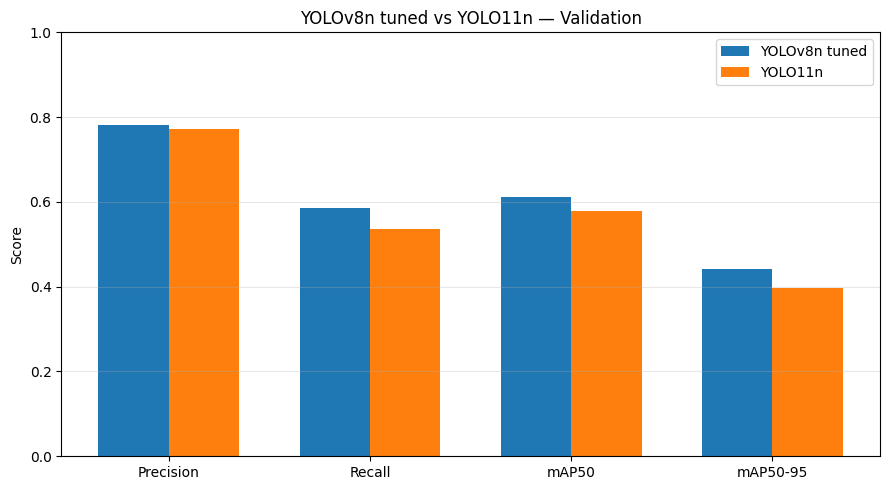


Plot saved:
/content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/day20_robustness/day20_model_comparison.png


In [11]:
# ============================================================
# 6. HEADLINE COMPARISON — SAFE VERSION
#    Validation + FPS without GPU OOM
# ============================================================

import gc
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# GPU cleanup helper
# ------------------------------------------------------------

def clear_gpu():
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()


# ------------------------------------------------------------
# SAFE FPS FUNCTION
# Loads ONE model at a time
# ------------------------------------------------------------

def measure_fps_safe(best_pt, val_img_dir, imgsz, max_images=10):

    clear_gpu()

    best_pt = Path(best_pt)
    val_img_dir = Path(val_img_dir)

    if not best_pt.exists():
        raise FileNotFoundError(f"Model not found:\n{best_pt}")

    image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

    images = sorted([
        p for p in val_img_dir.iterdir()
        if p.is_file() and p.suffix.lower() in image_exts
    ])

    images = images[:max_images]

    if len(images) == 0:
        raise FileNotFoundError(
            f"No validation images found:\n{val_img_dir}"
        )

    print("\n----------------------------------------")
    print("FPS measurement")
    print("Model :", best_pt)
    print("Images:", len(images))
    print("Size  :", imgsz)
    print("----------------------------------------")

    # Load ONLY this model
    temp_model = YOLO(str(best_pt))

    device = 0 if torch.cuda.is_available() else "cpu"

    # Warm-up
    temp_model.predict(
        source=str(images[0]),
        imgsz=imgsz,
        device=device,
        verbose=False
    )

    clear_gpu()

    times = []

    for image_path in images:

        clear_gpu()

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        start = time.perf_counter()

        temp_model.predict(
            source=str(image_path),
            imgsz=imgsz,
            device=device,
            verbose=False
        )

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        end = time.perf_counter()

        times.append(end - start)

    avg_time = float(np.mean(times))
    fps = 1.0 / avg_time

    print(f"Average inference time : {avg_time:.4f} sec/image")
    print(f"Average inference time : {avg_time * 1000:.2f} ms/image")
    print(f"FPS                    : {fps:.2f}")

    # IMPORTANT — release model
    del temp_model
    clear_gpu()

    return {
        "ms_per_image": avg_time * 1000,
        "fps": fps
    }


# ============================================================
# 6A. USE YOUR ALREADY-OBTAINED VALIDATION RESULTS
# ============================================================

# From your successful validation output:
#
# Model 1:
# P = 0.781
# R = 0.585
# mAP50 = 0.612
# mAP50-95 = 0.442
#
# Model 2:
# P = 0.773
# R = 0.537
# mAP50 = 0.578
# mAP50-95 = 0.397


# ------------------------------------------------------------
# Make sure paths are correct
# ------------------------------------------------------------

DAY17_BEST = Path(
    "/content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/"
    "day17_yolov8n_tuned_continuation/weights/best.pt"
)

DAY18_BEST = Path(
    "/content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/"
    "day18_yolo11n_640-4/weights/best.pt"
)

VAL_IMG_DIR = Path(
    "/content/TrashCAN_YOLO_Dataset_V1/images/val"
)

print("\nPATH CHECK")
print("Day 17:", DAY17_BEST)
print("Exists:", DAY17_BEST.exists())

print("\nDay 18:", DAY18_BEST)
print("Exists:", DAY18_BEST.exists())

print("\nValidation:", VAL_IMG_DIR)
print("Exists:", VAL_IMG_DIR.exists())


# ============================================================
# 6B. FPS — DAY 17 YOLOv8n
# ============================================================

FPS_DAY17 = measure_fps_safe(
    best_pt=DAY17_BEST,
    val_img_dir=VAL_IMG_DIR,
    imgsz=832,
    max_images=10
)


# ============================================================
# 6C. FPS — DAY 18 YOLO11n
# ============================================================

FPS_DAY18 = measure_fps_safe(
    best_pt=DAY18_BEST,
    val_img_dir=VAL_IMG_DIR,
    imgsz=640,
    max_images=10
)


# ============================================================
# 6D. HEADLINE COMPARISON TABLE
# ============================================================

HEADLINE = pd.DataFrame([
    {
        "Model": "YOLOv8n tuned",
        "Run": "day17_yolov8n_tuned_continuation",
        "Image size": 832,
        "Precision": 0.781,
        "Recall": 0.585,
        "mAP50": 0.612,
        "mAP50-95": 0.442,
        "ms / image": FPS_DAY17["ms_per_image"],
        "FPS": FPS_DAY17["fps"]
    },
    {
        "Model": "YOLO11n",
        "Run": "day18_yolo11n_640-4",
        "Image size": 640,
        "Precision": 0.773,
        "Recall": 0.537,
        "mAP50": 0.578,
        "mAP50-95": 0.397,
        "ms / image": FPS_DAY18["ms_per_image"],
        "FPS": FPS_DAY18["fps"]
    }
])

print("\n============================================================")
print("DAY 20 / DAY 21 HEADLINE COMPARISON")
print("============================================================")

display(HEADLINE.round(4))


# ============================================================
# 6E. METRIC DELTA
# ============================================================

b = HEADLINE.iloc[0]
t = HEADLINE.iloc[1]

delta = pd.DataFrame({
    "Metric": [
        "Precision",
        "Recall",
        "mAP50",
        "mAP50-95"
    ],

    "YOLOv8n tuned": [
        b["Precision"],
        b["Recall"],
        b["mAP50"],
        b["mAP50-95"]
    ],

    "YOLO11n": [
        t["Precision"],
        t["Recall"],
        t["mAP50"],
        t["mAP50-95"]
    ]
})

delta["YOLO11n - YOLOv8n"] = (
    delta["YOLO11n"] -
    delta["YOLOv8n tuned"]
)

print("\nMETRIC DIFFERENCE")
display(delta.round(4))


# ============================================================
# 6F. SAVE TABLE
# ============================================================

DAY20_ROOT = Path(
    "/content/drive/MyDrive/INTERNSHIPWORK/"
    "yolo_runs/day20_robustness"
)

DAY20_ROOT.mkdir(parents=True, exist_ok=True)

HEADLINE_PATH = DAY20_ROOT / "day20_headline_comparison.csv"
DELTA_PATH = DAY20_ROOT / "day20_metric_delta.csv"

HEADLINE.to_csv(HEADLINE_PATH, index=False)
delta.to_csv(DELTA_PATH, index=False)

print("\nSaved:")
print(HEADLINE_PATH)
print(DELTA_PATH)


# ============================================================
# 6G. PLOT
# ============================================================

metrics = [
    "Precision",
    "Recall",
    "mAP50",
    "mAP50-95"
]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    x - width/2,
    [
        b["Precision"],
        b["Recall"],
        b["mAP50"],
        b["mAP50-95"]
    ],
    width,
    label="YOLOv8n tuned"
)

ax.bar(
    x + width/2,
    [
        t["Precision"],
        t["Recall"],
        t["mAP50"],
        t["mAP50-95"]
    ],
    width,
    label="YOLO11n"
)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.set_title("YOLOv8n tuned vs YOLO11n — Validation")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

plot_path = DAY20_ROOT / "day20_model_comparison.png"
plt.savefig(plot_path, dpi=200)

plt.show()

print("\nPlot saved:")
print(plot_path)

## 21.7 Class-wise comparison

,Class,Train objects,Val objects,Baseline P,Baseline R,Baseline mAP50,Baseline mAP50-95,Tuned P,Tuned R,Tuned mAP50,Tuned mAP50-95,Change mAP50-95
0,trash_etc,1303,409,0.588,0.482,0.468,0.290,0.607,0.457,0.421,0.242,-0.048
1,trash_fabric,197,67,0.789,0.781,0.798,0.612,0.799,0.651,0.730,0.501,-0.111
2,trash_fishing_gear,110,69,0.699,0.573,0.513,0.309,0.596,0.551,0.552,0.323,0.014
3,trash_metal,718,225,0.767,0.622,0.630,0.450,0.772,0.542,0.612,0.411,-0.039
4,trash_paper,133,39,0.893,0.615,0.655,0.516,0.911,0.564,0.649,0.501,-0.015
5,trash_plastic,1181,374,0.781,0.655,0.750,0.544,0.793,0.596,0.698,0.493,-0.052
6,trash_rubber,90,29,0.938,0.345,0.467,0.350,1.000,0.379,0.411,0.311,-0.039
7,trash_wood,215,69,0.793,0.609,0.616,0.468,0.706,0.556,0.547,0.398,-0.071


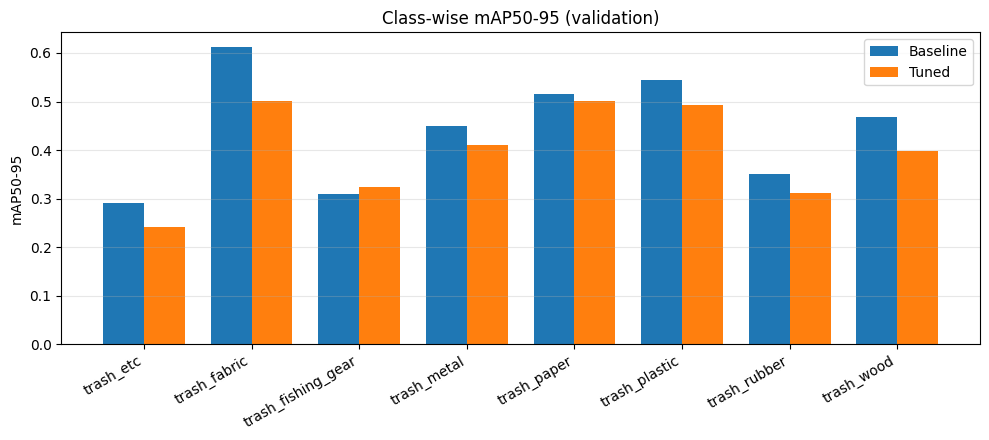

In [12]:
# ============================================================
# 7. CLASS-WISE RESULTS
# ============================================================
cb = {m["key"]: metrics_by_class(VAL_METRICS[m["key"]], len(CLASS_NAMES)) for m in MODELS}
train_counts = Counter()
for f in (V1_ROOT / "labels" / "train").glob("*.txt"):
    for ln in f.read_text().splitlines():
        if ln.strip(): train_counts[int(ln.split()[0])] += 1
val_counts = Counter()
for f in VAL_LBL_DIR.glob("*.txt"):
    for ln in f.read_text().splitlines():
        if ln.strip(): val_counts[int(ln.split()[0])] += 1

CLASS_TABLE = pd.DataFrame({
    "Class": CLASS_NAMES,
    "Train objects": [train_counts[i] for i in range(len(CLASS_NAMES))],
    "Val objects": [val_counts[i] for i in range(len(CLASS_NAMES))],
    "Baseline P": cb["baseline"]["P"], "Baseline R": cb["baseline"]["R"],
    "Baseline mAP50": cb["baseline"]["mAP50"], "Baseline mAP50-95": cb["baseline"]["mAP50_95"],
    "Tuned P": cb["tuned"]["P"], "Tuned R": cb["tuned"]["R"],
    "Tuned mAP50": cb["tuned"]["mAP50"], "Tuned mAP50-95": cb["tuned"]["mAP50_95"],
})
CLASS_TABLE["Change mAP50-95"] = CLASS_TABLE["Tuned mAP50-95"] - CLASS_TABLE["Baseline mAP50-95"]
display(CLASS_TABLE.round(3))

fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(CLASS_NAMES)); w = 0.38
ax.bar(x - w / 2, CLASS_TABLE["Baseline mAP50-95"], w, label="Baseline"); ax.bar(x + w / 2, CLASS_TABLE["Tuned mAP50-95"], w, label="Tuned")
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right"); ax.set_ylabel("mAP50-95")
ax.set_title("Class-wise mAP50-95 (validation)"); ax.grid(axis="y", alpha=0.3); ax.legend()
plt.tight_layout(); save_fig(fig, "day21_classwise_map.png"); plt.show()

## 21.8 Training behaviour — baseline vs tuned

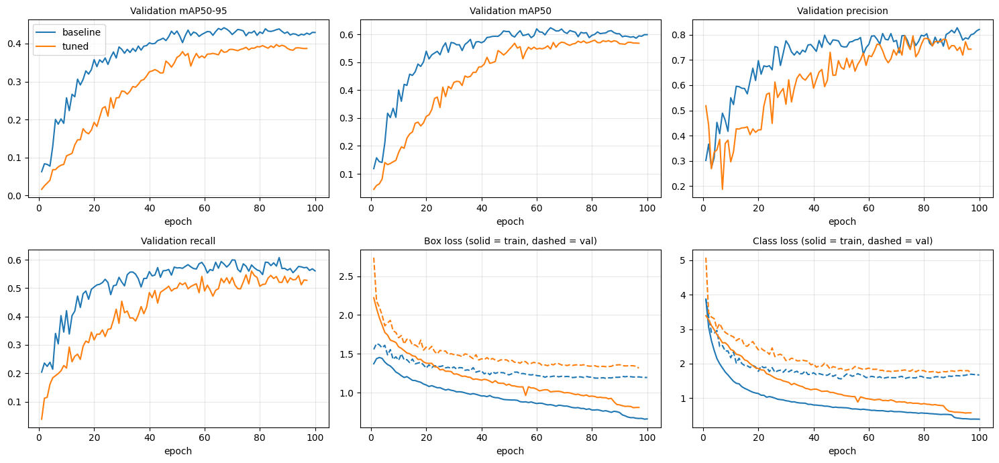

,Model,best epoch,last epoch,best val mAP50-95,final val mAP50-95,train box loss (final),val box loss (final),val/train box-loss ratio
0,baseline,67,100,0.4416,0.4292,0.6638,1.1967,1.8028
1,tuned,86,97,0.3973,0.3872,0.8112,1.3159,1.6222


In [13]:
# ============================================================
# 8. TRAINING CURVES + OVERFITTING CHECK
# ============================================================
curves = {m["key"]: read_results_csv(m["csv"]) for m in MODELS}
panels = [("metrics/mAP50-95(B)", "Validation mAP50-95"), ("metrics/mAP50(B)", "Validation mAP50"),
          ("metrics/precision(B)", "Validation precision"), ("metrics/recall(B)", "Validation recall"),
          ("train/box_loss", "Box loss (solid = train, dashed = val)"), ("train/cls_loss", "Class loss (solid = train, dashed = val)")]
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, (col, title) in zip(axes.ravel(), panels):
    for m in MODELS:
        df = curves[m["key"]]
        if col in df.columns:
            line, = ax.plot(df["epoch"], df[col], label=m["key"])
            vcol = col.replace("train/", "val/")
            if col.startswith("train/") and vcol in df.columns:
                ax.plot(df["epoch"], df[vcol], linestyle="--", color=line.get_color())
    ax.set_title(title, fontsize=10); ax.set_xlabel("epoch"); ax.grid(alpha=0.3)
axes[0][0].legend(); plt.tight_layout(); save_fig(fig, "day21_training_curves.png"); plt.show()

ov = []
for m in MODELS:
    df = curves[m["key"]]
    best_i = df["metrics/mAP50-95(B)"].idxmax()
    ov.append({"Model": m["key"], "best epoch": int(df.loc[best_i, "epoch"]), "last epoch": int(df["epoch"].iloc[-1]),
               "best val mAP50-95": float(df.loc[best_i, "metrics/mAP50-95(B)"]),
               "final val mAP50-95": float(df["metrics/mAP50-95(B)"].iloc[-1]),
               "train box loss (final)": float(df["train/box_loss"].iloc[-1]),
               "val box loss (final)": float(df["val/box_loss"].iloc[-1]),
               "val/train box-loss ratio": float(df["val/box_loss"].iloc[-1] / df["train/box_loss"].iloc[-1])})
OVERFIT_TABLE = pd.DataFrame(ov)
display(OVERFIT_TABLE.round(4))

## 21.9 Held-out test set (evaluated once)
The test split was not used for any tuning decision. It is evaluated here a single time for both models and the numbers are cached in `day21_test_results.json`; if the file exists, the cached numbers are shown instead of re-running. **Do not change the model or settings after looking at this table.**

In [14]:
# ============================================================
# 9. FINAL TEST EVALUATION (one time)
# ============================================================
TEST_FILE = OUT_DIR / "day21_test_results.json"
TEST_RES = None
if FINAL_TEST_EVALUATION:
    if TEST_FILE.exists() and not FORCE_RERUN_TEST:
        TEST_RES = json.loads(TEST_FILE.read_text())
        print("Test split was already evaluated — showing the cached numbers (no re-run).")
    else:
        TEST_RES = {}
        for m in MODELS:
            r, _ = run_val(m["model"], DATA_YAML, m["imgsz"], name=f"test_{m['key']}", split="test")
            TEST_RES[m["key"]] = {k: float(v) for k, v in r.items()}
        TEST_FILE.write_text(json.dumps({**TEST_RES, "run_baseline": BASELINE["run"], "run_tuned": TUNED["run"]}, indent=2))
        print("Test split evaluated and cached ->", TEST_FILE)
    TEST_RES = {k: v for k, v in TEST_RES.items() if k in ("baseline", "tuned")}
    test_rows = []
    for metric, key in [("Precision", "P"), ("Recall", "R"), ("F1", "F1"), ("mAP50", "mAP50"), ("mAP50-95", "mAP50_95")]:
        test_rows.append({"Metric": metric, "Val baseline": VAL_RES["baseline"][key], "Val tuned": VAL_RES["tuned"][key],
                          "Test baseline": TEST_RES["baseline"][key], "Test tuned": TEST_RES["tuned"][key],
                          "Test change (tuned - baseline)": TEST_RES["tuned"][key] - TEST_RES["baseline"][key]})
    TEST_TABLE = pd.DataFrame(test_rows)
    display(TEST_TABLE.round(4))
else:
    TEST_TABLE = None
    print("FINAL_TEST_EVALUATION is False — test split not evaluated.")

Test split was already evaluated — showing the cached numbers (no re-run).


,Metric,Val baseline,Val tuned,Test baseline,Test tuned,Test change (tuned - baseline)
0,Precision,0.7809,0.7729,0.9164,0.9013,-0.0151
1,Recall,0.5852,0.5370,0.9021,0.9002,-0.0019
2,F1,0.6690,0.6337,0.9092,0.9007,-0.0084
3,mAP50,0.6121,0.5775,0.9445,0.9257,-0.0188
4,mAP50-95,0.4424,0.3974,0.7161,0.6841,-0.0320


## 21.10 Project-specific study — robustness under difficult conditions (from Day 20)
The Day 20 notebook evaluated both variants under low visibility, clutter, occlusion and small-object conditions. Its saved table is loaded here so the presentation uses the exact Day 20 numbers.

In [15]:
# ============================================================
# 10. LOAD DAY 20 ROBUSTNESS RESULTS
# ============================================================
d20_file = DAY20_DIR / "day20_robustness_results_long.csv"
D20 = None
if d20_file.exists():
    d20 = pd.read_csv(d20_file)
    keys = {"baseline", TUNED_DAY20_KEY}
    sub = d20[d20.model_key.isin(keys)]
    if {"baseline", TUNED_DAY20_KEY}.issubset(set(sub.model_key)):
        D20 = sub[sub.group.isin(["natural", "synthetic"])].pivot_table(
            index=["challenge", "condition", "n_objects", "low_support"], columns="model_key",
            values=["mAP50_95", "delta_mAP50_95", "retention_%"]).round(4)
        display(D20)
        s = sub[sub.group == "synthetic"].pivot(index="condition", columns="model_key", values="retention_%")
        if len(s):
            fig, ax = plt.subplots(figsize=(12, 4.8))
            s[["baseline", TUNED_DAY20_KEY]].rename(columns={TUNED_DAY20_KEY: "tuned"}).plot(kind="bar", ax=ax, width=0.8)
            ax.axhline(100, color="black", linewidth=0.8); ax.set_ylabel("mAP50-95 retained (% of control)")
            ax.set_title("Robustness to synthetic degradations (Day 20)"); ax.grid(axis="y", alpha=0.3)
            plt.xticks(rotation=55, ha="right"); plt.tight_layout(); save_fig(fig, "day21_robustness_retention.png"); plt.show()
        ins = DAY20_DIR / "day20_research_insight.txt"
        if ins.exists():
            print("\nDay 20 research insight (saved text):\n" + ins.read_text(encoding="utf-8"))
    else:
        print("Day 20 results exist but do not contain the baseline and the selected tuned model:", sorted(set(d20.model_key)))
else:
    print(f"Day 20 results not found at {d20_file}. Run the Day 20 notebook first to include the robustness study.")

Day 20 results not found at /content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/day20_outputs/day20_robustness_results_long.csv. Run the Day 20 notebook first to include the robustness study.


## 21.11 Error analysis engine (validation set)
Both models are run once on every validation image (confidence ≥ 0.25). Each ground-truth object is classified as **correct**, **wrong class**, **poor localization** (IoU 0.1–0.5) or **missed**; each prediction that is not correct is a **background false positive**, **duplicate**, **wrong-class** or **localization** error. These records drive every gallery and table below.

In [18]:
# ============================================================
# 11. PER-IMAGE RECORDS — OOM-SAFE VERSION
# ============================================================

import gc
import torch
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# GPU CLEANUP
# ------------------------------------------------------------

def clear_gpu_memory():
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()


# ------------------------------------------------------------
# IMPORTANT:
# Do NOT keep both YOLO models in GPU simultaneously.
# We load one model, create records, move/delete it,
# then load the next model.
# ------------------------------------------------------------

clear_gpu_memory()

# ------------------------------------------------------------
# Validation images
# ------------------------------------------------------------

VAL_IMAGES_ALL = list_images(VAL_IMG_DIR)

print("Total validation images:", len(VAL_IMAGES_ALL))

# Use a controlled subset for detailed robustness analysis.
# This avoids unnecessary GPU memory/time usage.
ROBUSTNESS_MAX_IMAGES = min(200, len(VAL_IMAGES_ALL))

VAL_IMAGES = VAL_IMAGES_ALL[:ROBUSTNESS_MAX_IMAGES]

print("Images used for Day 20 detailed analysis:", len(VAL_IMAGES))


# ============================================================
# MODEL DEFINITIONS — PATHS
# ============================================================

DAY17_BEST = Path(
    "/content/drive/MyDrive/INTERNSHIPWORK/"
    "yolo_runs/day17_yolov8n_tuned_continuation/"
    "weights/best.pt"
)

DAY16_BEST = None

# Find Day 16 best checkpoint automatically
DAY16_CANDIDATES = sorted(
    PROJECT_DIR.glob("day16_yolov8n_img832*/weights/best.pt")
)

if DAY16_CANDIDATES:
    DAY16_BEST = DAY16_CANDIDATES[-1]

print("\nMODEL PATHS")
print("Day 17:", DAY17_BEST)
print("Day 17 exists:", DAY17_BEST.exists())

if DAY16_BEST:
    print("Day 16:", DAY16_BEST)
    print("Day 16 exists:", DAY16_BEST.exists())


# ============================================================
# HELPER — FIND MODEL CONFIGURATION
# ============================================================

MODEL_CONFIGS = []

if DAY16_BEST is not None and DAY16_BEST.exists():
    MODEL_CONFIGS.append({
        "key": "baseline",
        "name": "YOLOv8n Day 16",
        "best_pt": DAY16_BEST,
        "imgsz": 832
    })

if DAY17_BEST.exists():
    MODEL_CONFIGS.append({
        "key": "tuned",
        "name": "YOLOv8n Day 17",
        "best_pt": DAY17_BEST,
        "imgsz": 832
    })

if not MODEL_CONFIGS:
    raise FileNotFoundError(
        "No valid Day 16/17 best.pt files were found."
    )

print("\nModels selected:")
for m in MODEL_CONFIGS:
    print(m["key"], "->", m["best_pt"])


# ============================================================
# SEQUENTIAL PREDICTION
# ============================================================

REC = {}

for m in MODEL_CONFIGS:

    print("\n" + "=" * 70)
    print("PROCESSING:", m["name"])
    print("CHECKPOINT:", m["best_pt"])
    print("=" * 70)

    clear_gpu_memory()

    # Load ONLY ONE MODEL
    temp_model = YOLO(str(m["best_pt"]))

    print("Model loaded.")

    # --------------------------------------------------------
    # Predict
    # --------------------------------------------------------

    current_records = predict_records(
        temp_model,
        VAL_IMAGES,
        VAL_LBL_DIR,
        m["imgsz"],
        conf=CONF_EVAL
    )

    # --------------------------------------------------------
    # Store records on CPU / Python side
    # --------------------------------------------------------

    REC[m["key"]] = current_records

    print(
        f"{m['name']} completed: "
        f"{len(current_records)} image records"
    )

    # --------------------------------------------------------
    # CRITICAL: release model BEFORE next model
    # --------------------------------------------------------

    del temp_model

    clear_gpu_memory()

    print("GPU memory cleared.")


# ============================================================
# CHECK IMAGE ALIGNMENT
# ============================================================

if "baseline" in REC and "tuned" in REC:

    assert (
        [r["image"] for r in REC["baseline"]]
        ==
        [r["image"] for r in REC["tuned"]]
    )

    RB = REC["baseline"]
    RT = REC["tuned"]

else:
    raise RuntimeError(
        "Both baseline and tuned records are required."
    )


n_img = len(VAL_IMAGES)

print("\nBoth models completed successfully.")
print("Images analyzed:", n_img)


# ============================================================
# OBJECT-LEVEL TABLE
# ============================================================

obj_tables = []

for m in MODEL_CONFIGS:

    key = m["key"]

    obj_tables.append(
        records_to_object_table(
            REC[key],
            CLASS_NAMES,
            key
        )
    )

obj_df = pd.concat(
    obj_tables,
    ignore_index=True
)


# ============================================================
# FALSE-POSITIVE TABLE
# ============================================================

fp_tables = []

for m in MODEL_CONFIGS:

    key = m["key"]

    fp_tables.append(
        records_to_fp_table(
            REC[key],
            CLASS_NAMES,
            key
        )
    )

fp_df = pd.concat(
    fp_tables,
    ignore_index=True
)


# ============================================================
# OBJECT OUTCOMES
# ============================================================

outcome_tbl = (
    obj_df
    .groupby("model")["outcome"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .reindex(
        columns=[
            "correct",
            "wrong_class",
            "poor_localization",
            "missed"
        ],
        fill_value=0
    )
)

outcome_tbl["objects"] = (
    obj_df.groupby("model").size()
)

print(
    f"\nGround-truth outcomes at "
    f"conf >= {CONF_EVAL}, IoU >= 0.5:"
)

display(outcome_tbl.round(3))


# ============================================================
# FALSE POSITIVE TYPES
# ============================================================

fp_tbl = (
    fp_df
    .groupby(["model", "kind"])
    .size()
    .unstack(fill_value=0)
    .reindex(
        columns=[
            "background",
            "duplicate",
            "wrong_class",
            "localization"
        ],
        fill_value=0
    )
)

fp_tbl[
    "false positives / image (background+duplicate)"
] = (
    fp_tbl["background"] +
    fp_tbl["duplicate"]
) / n_img

print("\nPrediction error types:")
display(fp_tbl.round(3))


# ============================================================
# OBJECT-SIZE ANALYSIS
# ============================================================

size_rows = []

for key in ["baseline", "tuned"]:

    o = obj_df[obj_df.model == key]

    for sz in ["small", "medium", "large"]:

        s = o[o["size"] == sz]

        size_rows.append({
            "model": key,
            "size": sz,
            "objects": len(s),

            "recall": (
                (s.outcome == "correct").mean()
                if len(s) else np.nan
            ),

            "missed": (
                (s.outcome == "missed").mean()
                if len(s) else np.nan
            ),

            "wrong_class": (
                (s.outcome == "wrong_class").mean()
                if len(s) else np.nan
            ),

            "poor_localization": (
                (s.outcome == "poor_localization").mean()
                if len(s) else np.nan
            )
        })


SIZE_TBL = pd.DataFrame(size_rows)

print(
    "\nObject-size analysis "
    "(small <= 1% of image area):"
)

display(SIZE_TBL.round(3))


# ============================================================
# CLASS-WISE RECALL
# ============================================================

cls_rec = (
    obj_df
    .assign(ok=(obj_df.outcome == "correct"))
    .pivot_table(
        index="gt_class",
        columns="model",
        values="ok",
        aggfunc="mean"
    )
)

# Add training-object count only if available
if "train_counts" in globals():

    cls_rec["train objects"] = [
        train_counts[CLASS_NAMES.index(c)]
        for c in cls_rec.index
    ]


CLASS_RECALL = cls_rec.sort_values(
    "baseline"
)

print("\nClass-wise object recall:")
display(CLASS_RECALL.round(3))


# ============================================================
# SAVE DAY 20 RESULTS
# ============================================================

DAY20_ROOT = Path(
    "/content/drive/MyDrive/INTERNSHIPWORK/"
    "yolo_runs/day20_robustness"
)

DAY20_ROOT.mkdir(
    parents=True,
    exist_ok=True
)

outcome_tbl.to_csv(
    DAY20_ROOT / "day20_object_outcomes.csv"
)

fp_tbl.to_csv(
    DAY20_ROOT / "day20_false_positive_analysis.csv"
)

SIZE_TBL.to_csv(
    DAY20_ROOT / "day20_object_size_analysis.csv",
    index=False
)

CLASS_RECALL.to_csv(
    DAY20_ROOT / "day20_classwise_recall.csv"
)

print("\n============================================================")
print("DAY 20 ANALYSIS SAVED")
print("============================================================")

print(
    DAY20_ROOT / "day20_object_outcomes.csv"
)

print(
    DAY20_ROOT / "day20_false_positive_analysis.csv"
)

print(
    DAY20_ROOT / "day20_object_size_analysis.csv"
)

print(
    DAY20_ROOT / "day20_classwise_recall.csv"
)

# Final cleanup
clear_gpu_memory()

print("\nGPU memory released.")

Total validation images: 1204
Images used for Day 20 detailed analysis: 200

MODEL PATHS
Day 17: /content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/day17_yolov8n_tuned_continuation/weights/best.pt
Day 17 exists: True
Day 16: /content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/day16_yolov8n_img832-8/weights/best.pt
Day 16 exists: True

Models selected:
baseline -> /content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/day16_yolov8n_img832-8/weights/best.pt
tuned -> /content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/day17_yolov8n_tuned_continuation/weights/best.pt

PROCESSING: YOLOv8n Day 16
CHECKPOINT: /content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/day16_yolov8n_img832-8/weights/best.pt
Model loaded.
YOLOv8n Day 16 completed: 200 image records
GPU memory cleared.

PROCESSING: YOLOv8n Day 17
CHECKPOINT: /content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/day17_yolov8n_tuned_continuation/weights/best.pt
Model loaded.
YOLOv8n Day 17 completed: 200 image records
GPU memory cleared.

Both models completed succe

outcome,correct,wrong_class,poor_localization,missed,objects
model,,,,,
baseline,0.397,0.182,0.024,0.397,292
tuned,0.401,0.158,0.024,0.418,292



Prediction error types:


kind,background,duplicate,wrong_class,localization,false positives / image (background+duplicate)
model,,,,,
baseline,63,17,53,7,0.40
tuned,42,16,46,7,0.29



Object-size analysis (small <= 1% of image area):


,model,size,objects,recall,missed,wrong_class,poor_localization
0,baseline,small,157,0.204,0.567,0.210,0.019
1,baseline,medium,89,0.573,0.258,0.169,0.000
2,baseline,large,46,0.717,0.087,0.109,0.087
3,tuned,small,157,0.236,0.599,0.159,0.006
4,tuned,medium,89,0.551,0.225,0.213,0.011
5,tuned,large,46,0.674,0.174,0.043,0.109



Class-wise object recall:


model,baseline,tuned,train objects
gt_class,,,
trash_fabric,0.000,0.000,197
trash_etc,0.291,0.342,1303
trash_metal,0.378,0.378,718
trash_plastic,0.635,0.519,1181
trash_wood,0.667,0.633,215



DAY 20 ANALYSIS SAVED
/content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/day20_robustness/day20_object_outcomes.csv
/content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/day20_robustness/day20_false_positive_analysis.csv
/content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/day20_robustness/day20_object_size_analysis.csv
/content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/day20_robustness/day20_classwise_recall.csv

GPU memory released.


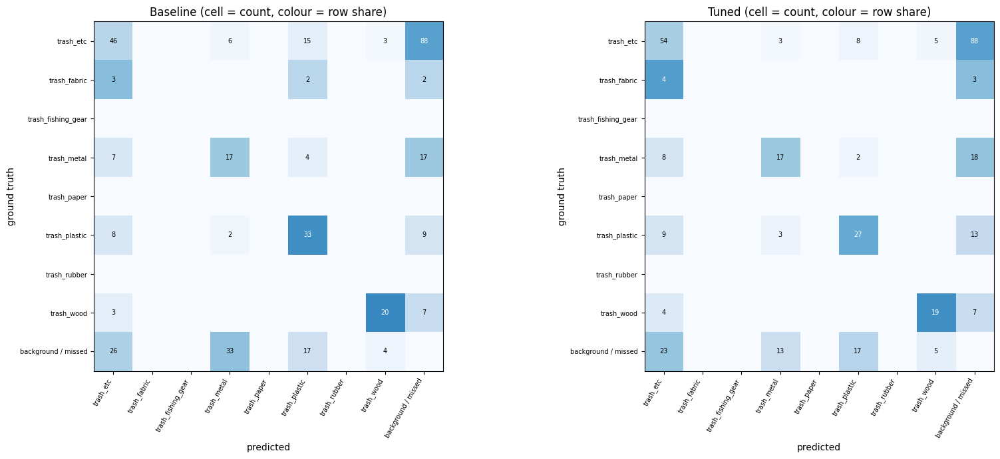

baseline: top class confusions (true -> predicted, count): [('trash_etc', 'trash_plastic', 15), ('trash_plastic', 'trash_etc', 8), ('trash_metal', 'trash_etc', 7), ('trash_etc', 'trash_metal', 6), ('trash_metal', 'trash_plastic', 4)]
tuned: top class confusions (true -> predicted, count): [('trash_plastic', 'trash_etc', 9), ('trash_etc', 'trash_plastic', 8), ('trash_metal', 'trash_etc', 8), ('trash_etc', 'trash_wood', 5), ('trash_fabric', 'trash_etc', 4)]


In [19]:
# ============================================================
# 11b. CONFUSION MATRICES (objects, conf >= 0.25)
# ============================================================
def confusion_from_records(records, n):
    cm = np.zeros((n + 1, n + 1), int)   # rows: ground truth (last = background); cols: prediction (last = missed)
    for r in records:
        for i, o in enumerate(r["gt_out"]):
            g = int(r["gt_cls"][i])
            if o["outcome"] == "correct": cm[g, g] += 1
            elif o["outcome"] == "wrong_class": cm[g, o["pred"]] += 1
            else: cm[g, n] += 1
        for j, p in enumerate(r["pr_out"]):
            if p["kind"] in ("background", "duplicate"):
                cm[n, int(r["pr_cls"][j])] += 1
    return cm

n = len(CLASS_NAMES); labels = CLASS_NAMES + ["background / missed"]
CM = {k: confusion_from_records(REC[k], n) for k in ["baseline", "tuned"]}
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
for ax, k in zip(axes, ["baseline", "tuned"]):
    cm = CM[k]; norm = cm / np.maximum(cm.sum(1, keepdims=True), 1)
    im = ax.imshow(norm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(n + 1)); ax.set_yticks(range(n + 1))
    ax.set_xticklabels(labels, rotation=60, ha="right", fontsize=7); ax.set_yticklabels(labels if True else [], fontsize=7)
    for i in range(n + 1):
        for j in range(n + 1):
            if cm[i, j]: ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=7, color="white" if norm[i, j] > 0.5 else "black")
    ax.set_xlabel("predicted"); ax.set_ylabel("ground truth"); ax.set_title(f"{k.capitalize()} (cell = count, colour = row share)")
plt.tight_layout(); save_fig(fig, "day21_confusion_matrices.png"); plt.show()

def top_confusions(cm, k=5):
    rows = [(CLASS_NAMES[i], CLASS_NAMES[j], int(cm[i, j])) for i in range(n) for j in range(n) if i != j and cm[i, j] > 0]
    return sorted(rows, key=lambda r: -r[2])[:k]
TOP_CONF = {k: top_confusions(CM[k]) for k in CM}
for k in CM:
    print(f"{k}: top class confusions (true -> predicted, count):", TOP_CONF[k])

## 21.12 Representative successes
Left: ground truth. Middle: baseline. Right: tuned. Green boxes are correct detections.

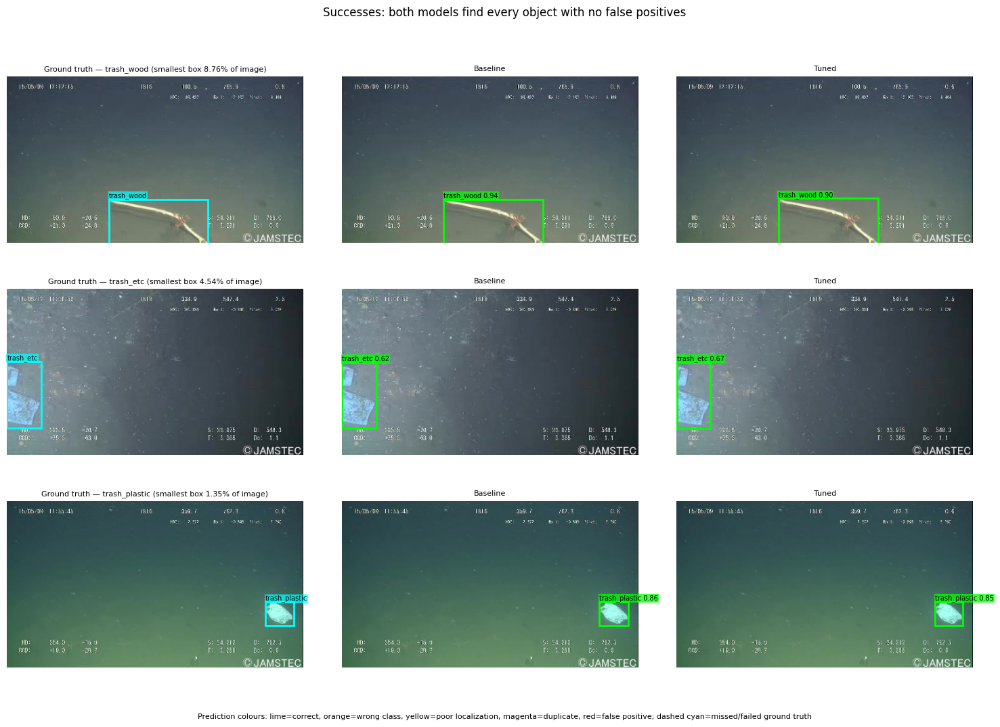

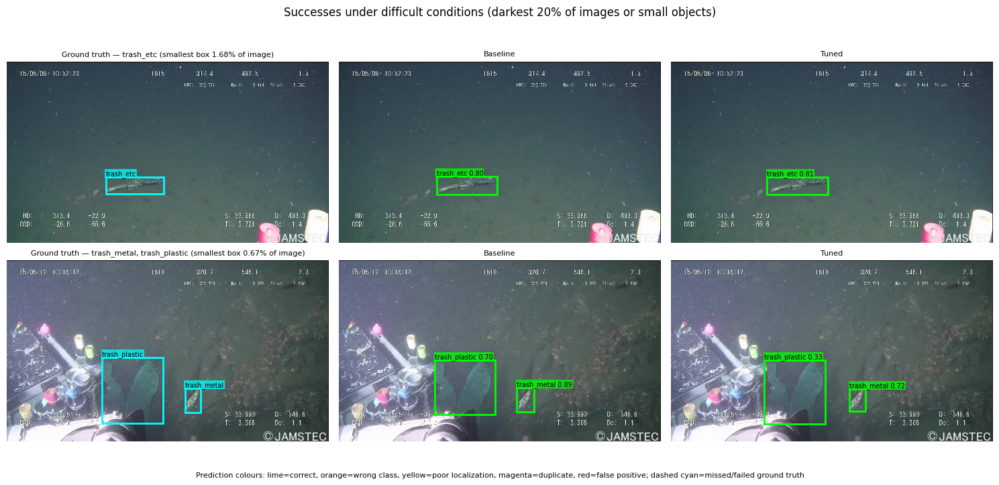

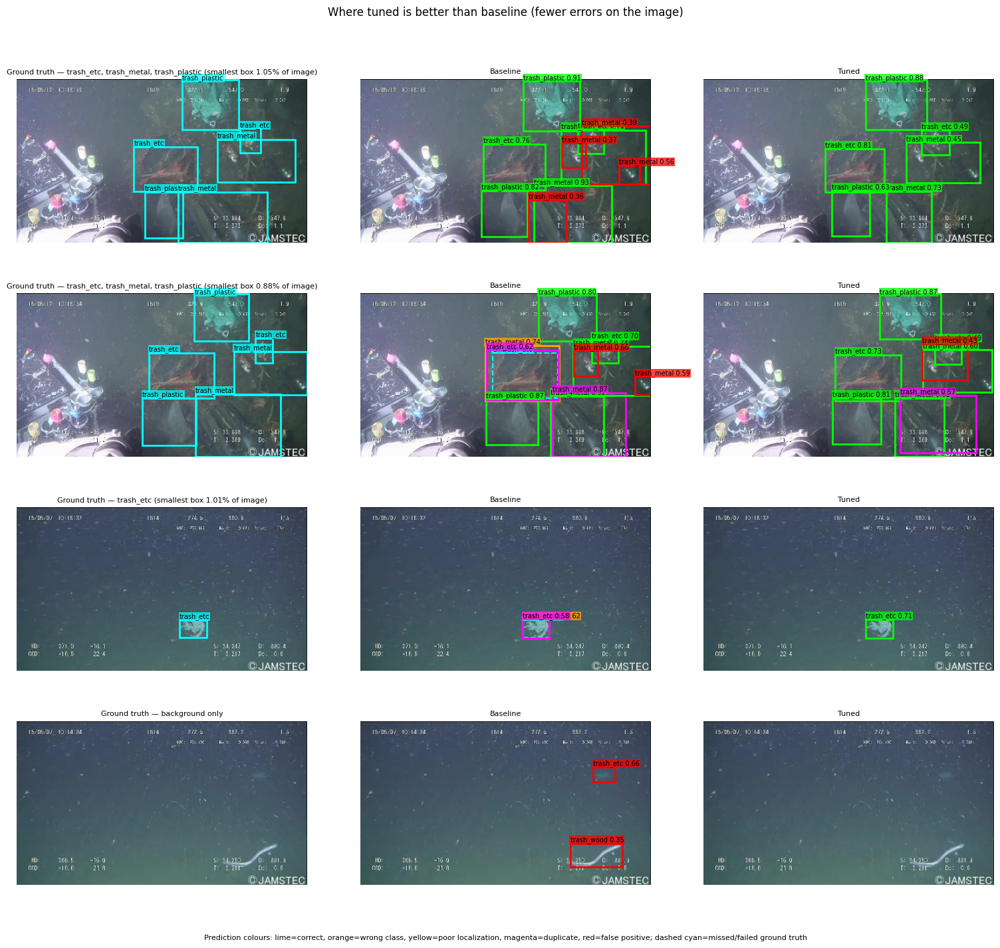

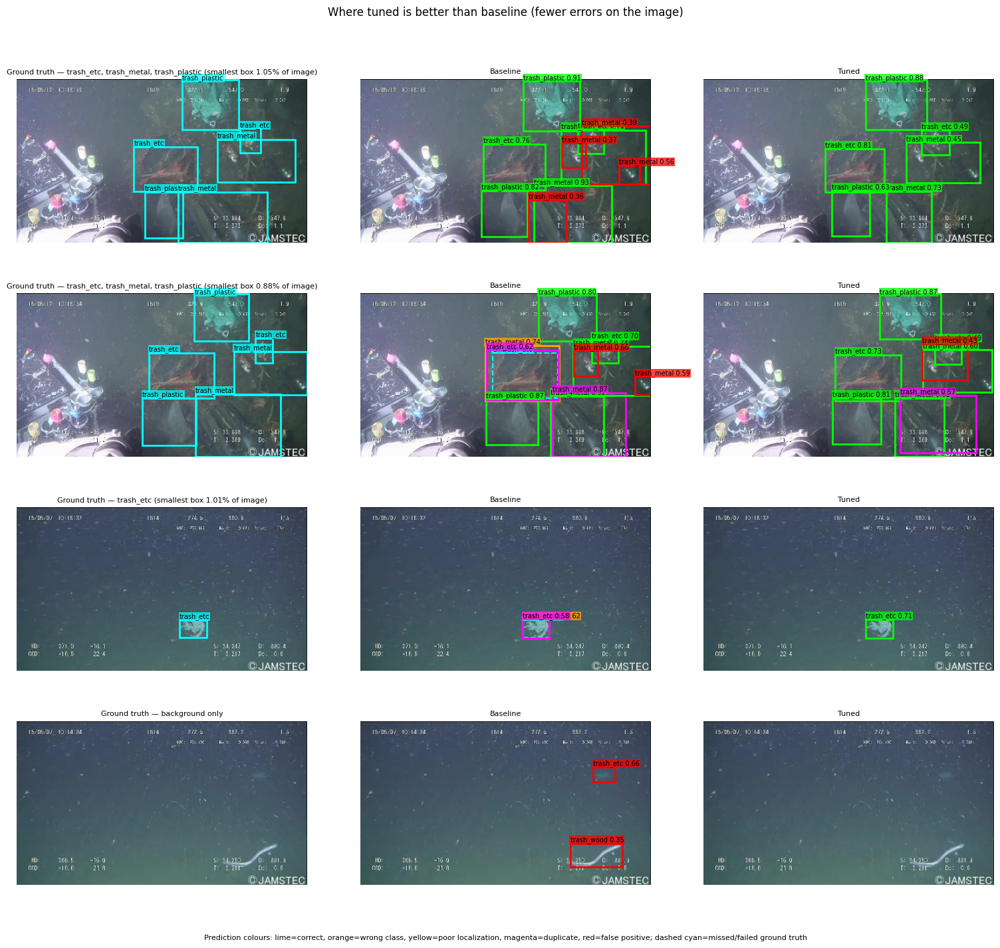

In [20]:
# ============================================================
# 12. SUCCESS GALLERIES
# ============================================================
_gray = {}
def brightness(rec):
    if rec["image"] not in _gray:
        _gray[rec["image"]] = float(cv2.cvtColor(cv2.imread(rec["path"]), cv2.COLOR_BGR2GRAY).mean())
    return _gray[rec["image"]]
dark_thr = np.quantile([brightness(r) for r in RB], 0.20)
def is_dark(rec): return brightness(rec) <= dark_thr
def has_small(rec): return bool(len(rec["gt_area"]) and (rec["gt_area"] <= SMALL_AREA).any())
def caption(rec):
    if not len(rec["gt_cls"]): return "background only"
    names = ", ".join(sorted({CLASS_NAMES[int(c)] for c in rec["gt_cls"]}))
    return f"{names} (smallest box {100 * rec['gt_area'].min():.2f}% of image)"
def pairs(pred, score=None, diverse=True, limit=N_GALLERY):
    cand = [(a, b) for a, b in zip(RB, RT) if pred(a, b)]
    if score: cand.sort(key=lambda ab: score(*ab), reverse=True)
    out, seen = [], set()
    for a, b in cand:
        key = int(a["gt_cls"][0]) if (diverse and len(a["gt_cls"])) else None
        if diverse and key in seen and len(seen) < len(CLASS_NAMES) and len(cand) > limit:
            continue
        seen.add(key); out.append((a, b, caption(a)))
        if len(out) >= limit: break
    return out

def all_correct(r): return len(r["gt_out"]) > 0 and all(o["outcome"] == "correct" for o in r["gt_out"]) \
                           and not any(p["kind"] in ("background", "duplicate") for p in r["pr_out"])
def mean_iou(r): return float(np.mean([o["iou"] for o in r["gt_out"]])) if r["gt_out"] else 0.0

both_ok = pairs(lambda a, b: all_correct(a) and all_correct(b), score=lambda a, b: min(mean_iou(a), mean_iou(b)))
gallery(both_ok, VAL_IMG_DIR, CLASS_NAMES, LABELS, "Successes: both models find every object with no false positives",
        save_path=OUT_DIR / "figures" / "day21_successes.png")

hard_ok = pairs(lambda a, b: all_correct(a) and all_correct(b) and (is_dark(a) or has_small(a)),
                score=lambda a, b: min(mean_iou(a), mean_iou(b)))
gallery(hard_ok, VAL_IMG_DIR, CLASS_NAMES, LABELS, "Successes under difficult conditions (darkest 20% of images or small objects)",
        save_path=OUT_DIR / "figures" / "day21_successes_difficult.png")

tuned_wins = pairs(lambda a, b: image_error_count(a) - image_error_count(b) >= 1,
                   score=lambda a, b: image_error_count(a) - image_error_count(b), diverse=False)
gallery(tuned_wins, VAL_IMG_DIR, CLASS_NAMES, LABELS, "Where tuned is better than baseline (fewer errors on the image)",
        save_path=OUT_DIR / "figures" / "day21_tuned_better.png")

## 21.13 Representative failures
Dashed cyan boxes mark ground-truth objects the model missed, mislabelled or badly localized. Orange = wrong class, yellow = poor localization, magenta = duplicate, red = false positive.

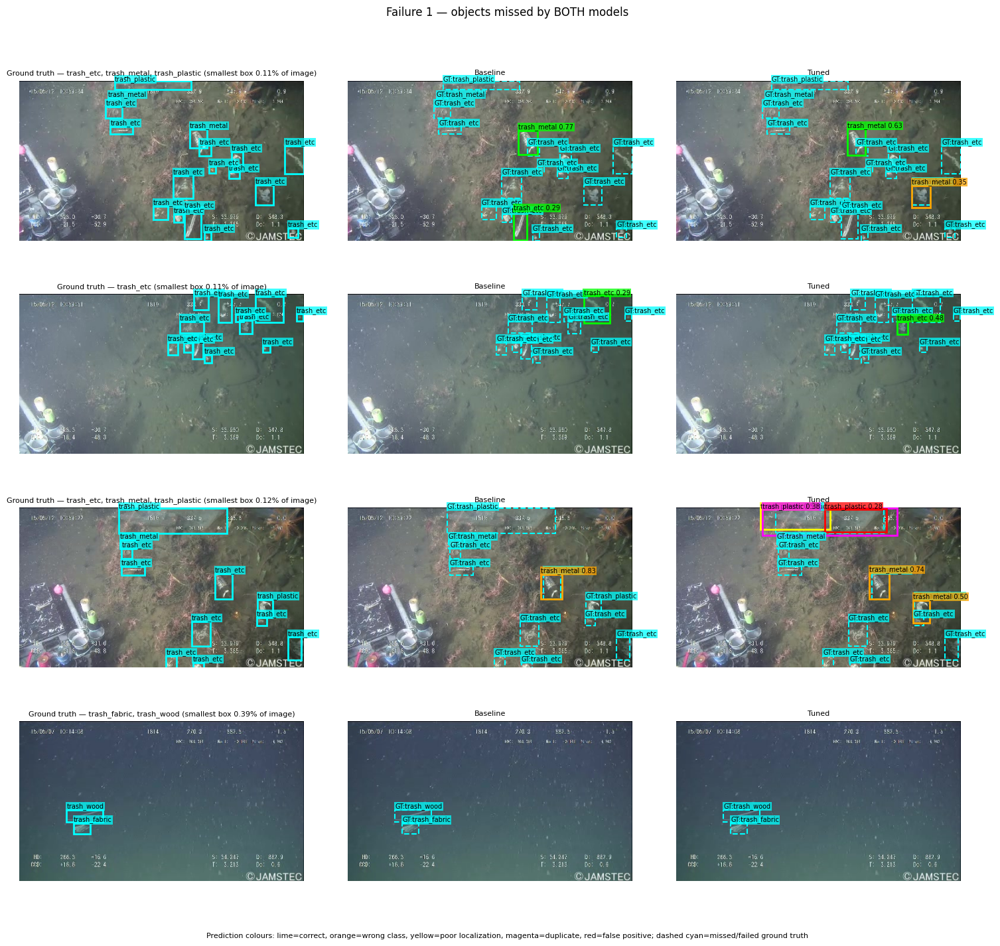

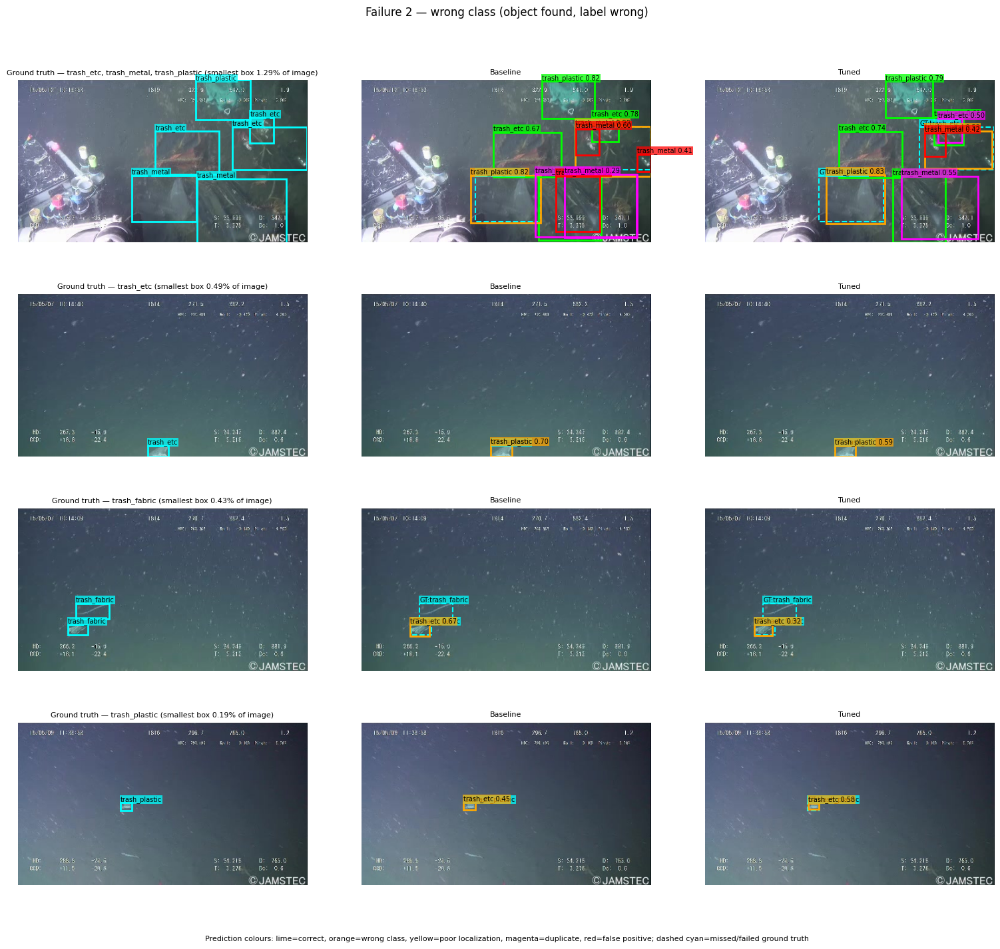

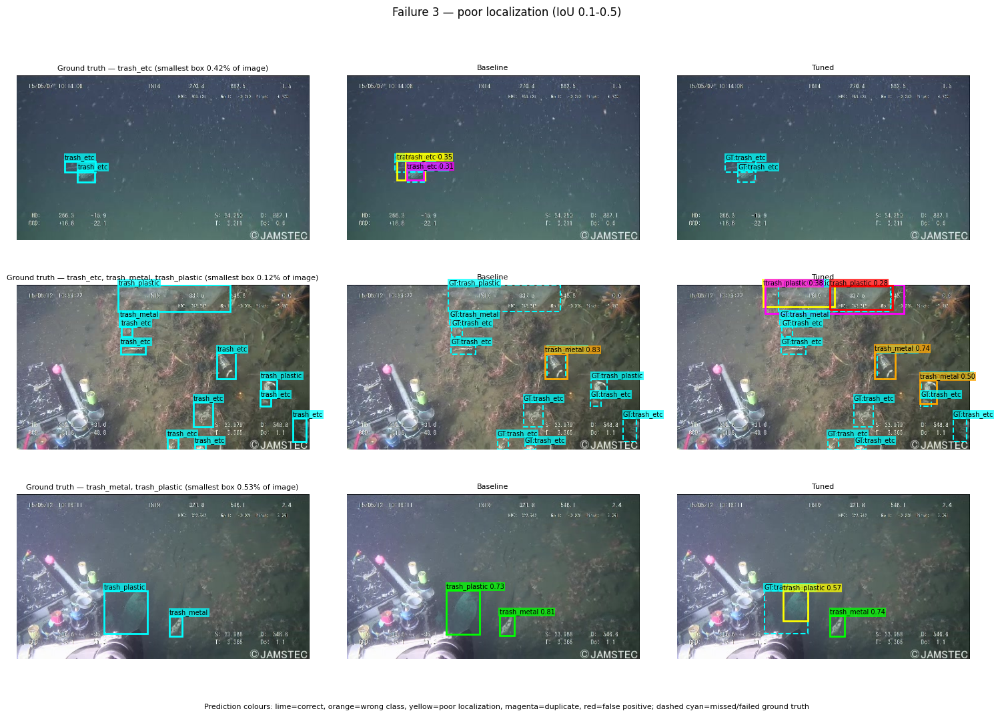

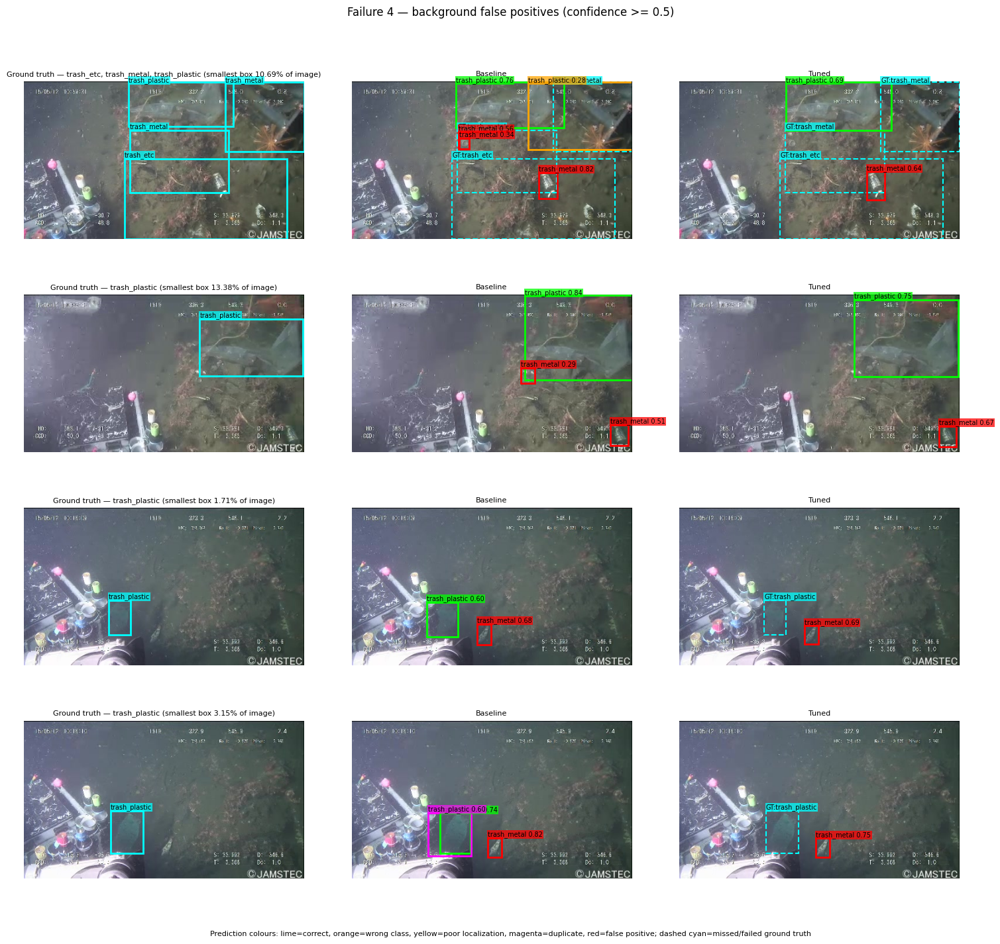

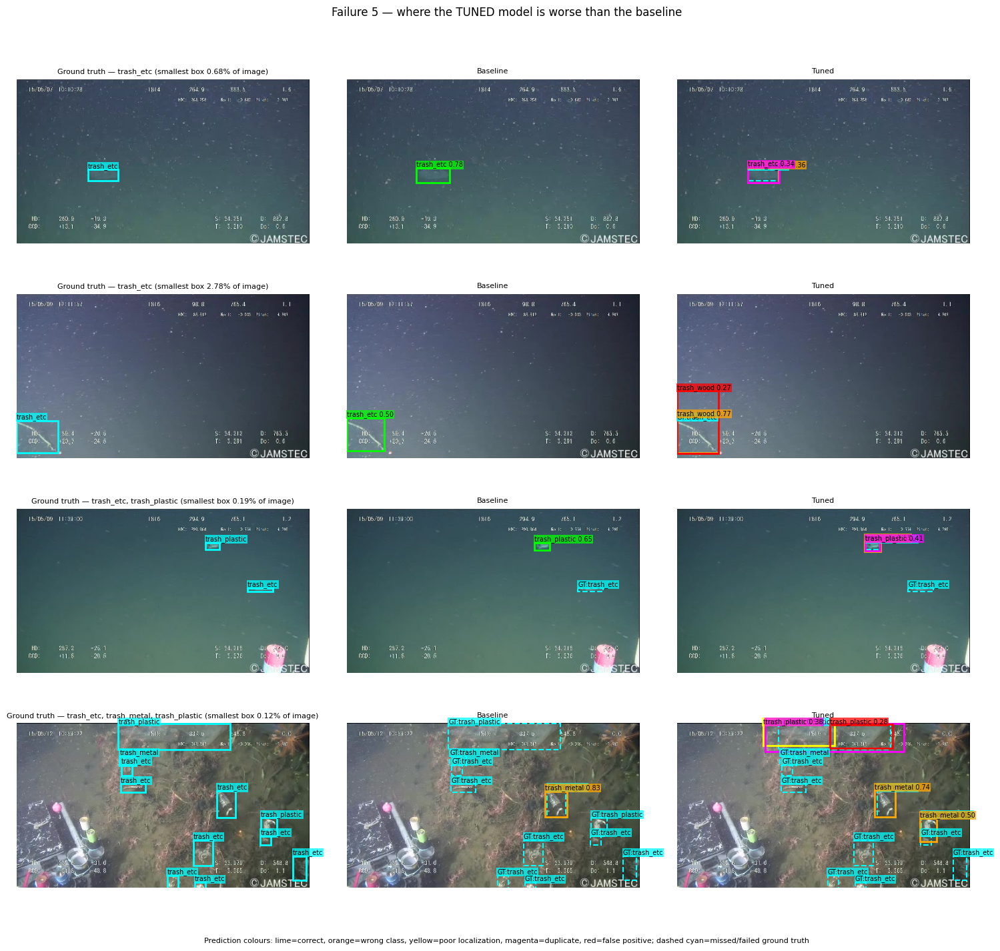

,images
error-free in both,52
errors only in baseline,26
errors only in tuned,24
errors in both,98


In [21]:
# ============================================================
# 13. FAILURE GALLERIES
# ============================================================
def n_out(r, name): return sum(o["outcome"] == name for o in r["gt_out"])

missed_both = pairs(lambda a, b: n_out(a, "missed") > 0 and n_out(b, "missed") > 0,
                    score=lambda a, b: n_out(a, "missed") + n_out(b, "missed"))
gallery(missed_both, VAL_IMG_DIR, CLASS_NAMES, LABELS, "Failure 1 — objects missed by BOTH models", save_path=OUT_DIR / "figures" / "day21_fail_missed.png")

wrong_cls = pairs(lambda a, b: n_out(a, "wrong_class") + n_out(b, "wrong_class") > 0,
                  score=lambda a, b: n_out(a, "wrong_class") + n_out(b, "wrong_class"))
gallery(wrong_cls, VAL_IMG_DIR, CLASS_NAMES, LABELS, "Failure 2 — wrong class (object found, label wrong)", save_path=OUT_DIR / "figures" / "day21_fail_wrong_class.png")

loc_err = pairs(lambda a, b: n_out(a, "poor_localization") + n_out(b, "poor_localization") > 0,
                score=lambda a, b: n_out(a, "poor_localization") + n_out(b, "poor_localization"))
gallery(loc_err, VAL_IMG_DIR, CLASS_NAMES, LABELS, "Failure 3 — poor localization (IoU 0.1-0.5)", save_path=OUT_DIR / "figures" / "day21_fail_localization.png")

def n_bg_fp(r, thr=0.5): return sum(p["kind"] == "background" and c >= thr for p, c in zip(r["pr_out"], r["pr_conf"]))
false_pos = pairs(lambda a, b: n_bg_fp(a) + n_bg_fp(b) > 0, score=lambda a, b: n_bg_fp(a) + n_bg_fp(b), diverse=False)
gallery(false_pos, VAL_IMG_DIR, CLASS_NAMES, LABELS, "Failure 4 — background false positives (confidence >= 0.5)", save_path=OUT_DIR / "figures" / "day21_fail_false_positive.png")

base_wins = pairs(lambda a, b: image_error_count(b) - image_error_count(a) >= 1,
                  score=lambda a, b: image_error_count(b) - image_error_count(a), diverse=False)
gallery(base_wins, VAL_IMG_DIR, CLASS_NAMES, LABELS, "Failure 5 — where the TUNED model is worse than the baseline", save_path=OUT_DIR / "figures" / "day21_tuned_worse.png")

both_bad = sum(1 for a, b in zip(RB, RT) if image_error_count(a) > 0 and image_error_count(b) > 0)
only_base = sum(1 for a, b in zip(RB, RT) if image_error_count(a) > 0 and image_error_count(b) == 0)
only_tuned = sum(1 for a, b in zip(RB, RT) if image_error_count(a) == 0 and image_error_count(b) > 0)
clean_both = n_img - both_bad - only_base - only_tuned
IMAGE_AGREEMENT = pd.DataFrame({"images": [clean_both, only_base, only_tuned, both_bad]},
                               index=["error-free in both", "errors only in baseline", "errors only in tuned", "errors in both"])
display(IMAGE_AGREEMENT)

## 21.14 Unusual errors
Mistakes that are surprising rather than typical: high-confidence errors, huge boxes, detections on background-only images, duplicates, and **objects that both models confidently detect but that have no ground-truth label** (possible annotation gaps).

model,baseline,tuned
confident background FPs (conf>=0.7),3,3
confident wrong-class (conf>=0.7),21,10
oversized wrong boxes (>=25% of image),2,0
duplicate detections,17,16
background-only images,28,28
...with any detection,10,8
...with a confident detection,1,2


Images where BOTH models confidently (>=0.5) detect the same object that has no ground-truth match: 4
These are either true false alarms shared by both models or possible missing annotations — inspect manually.


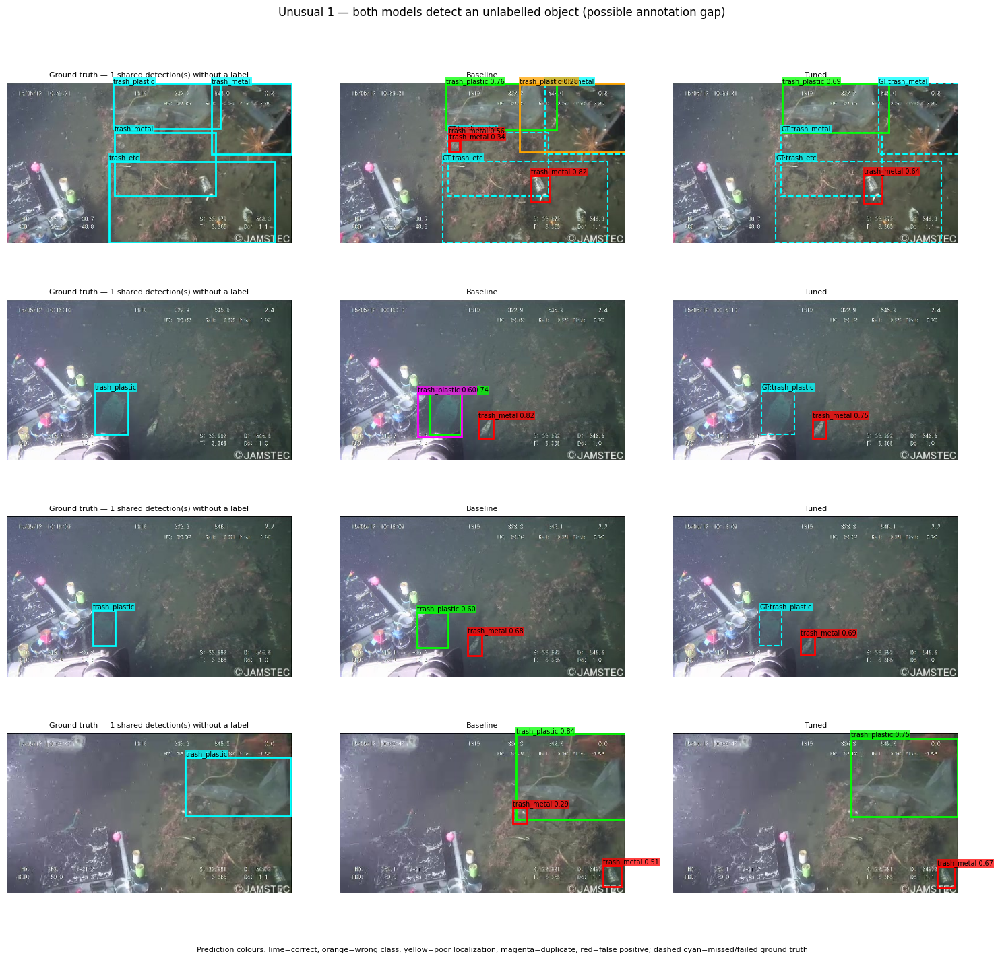

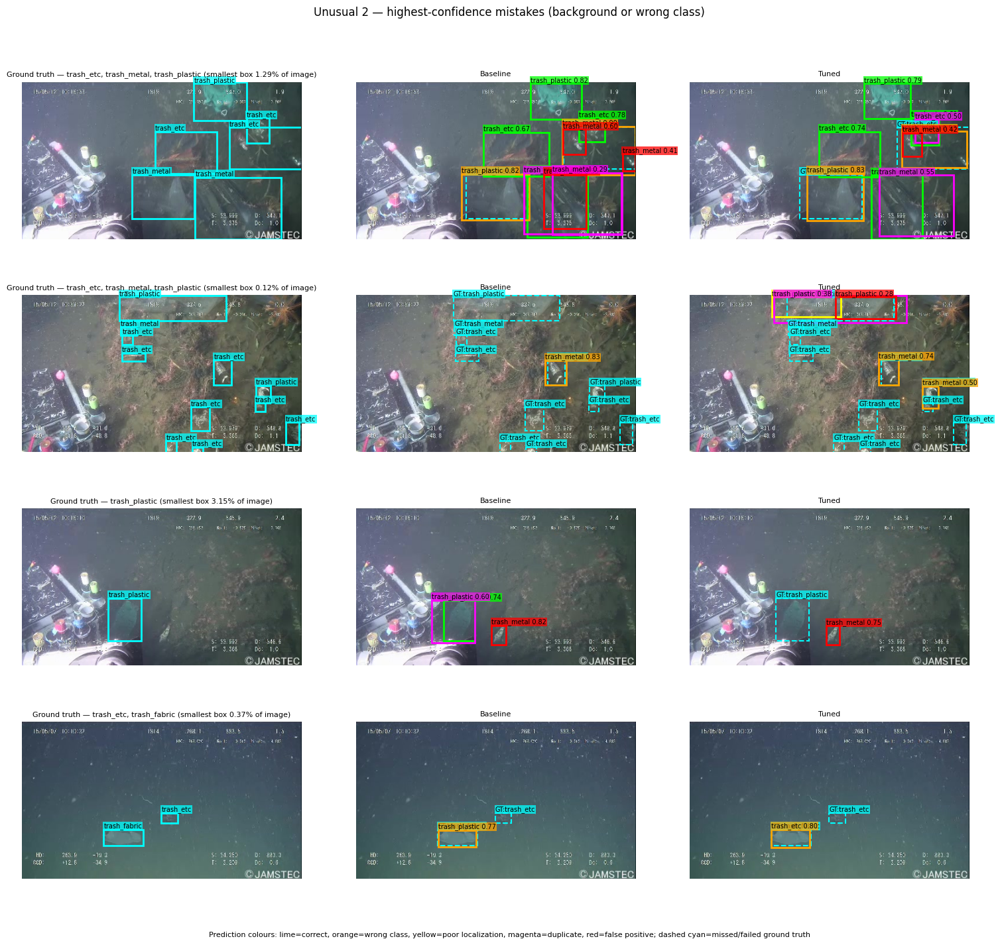

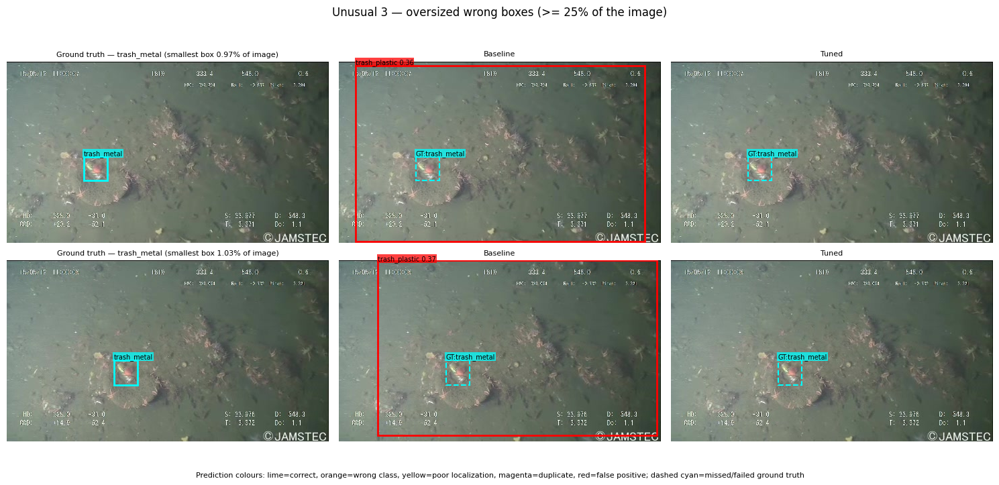

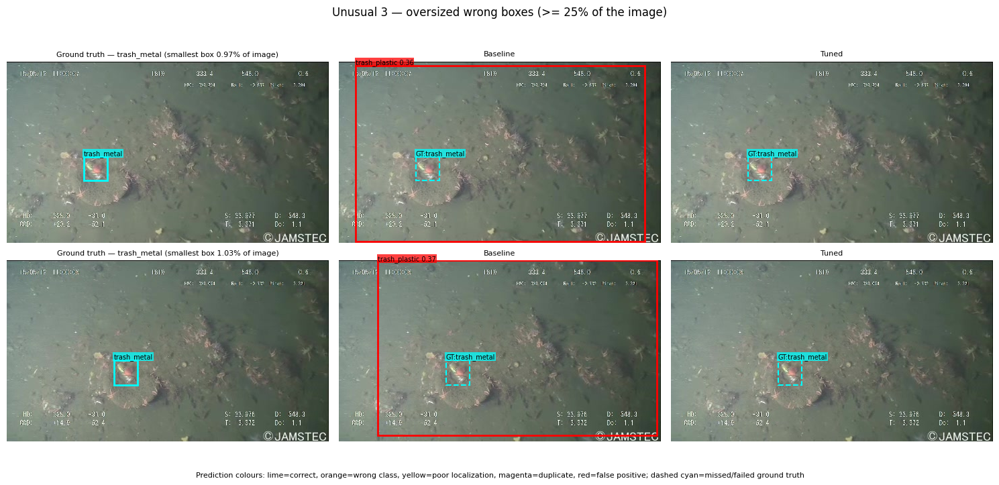

In [22]:
# ============================================================
# 14. UNUSUAL ERRORS
# ============================================================
unusual_rows = []
for key in ["baseline", "tuned"]:
    f = fp_df[fp_df.model == key]; recs = REC[key]
    bg_only = [r for r in recs if len(r["gt_cls"]) == 0]
    bg_only_fp = [r for r in bg_only if len(r["pr_cls"]) > 0]
    bg_only_conf = [r for r in bg_only if len(r["pr_cls"]) and r["pr_conf"].max() >= UNUSUAL_CONF]
    unusual_rows.append({
        "model": key,
        f"confident background FPs (conf>={UNUSUAL_CONF})": int(((f.kind == "background") & (f.conf >= UNUSUAL_CONF)).sum()),
        f"confident wrong-class (conf>={UNUSUAL_CONF})": int(((f.kind == "wrong_class") & (f.conf >= UNUSUAL_CONF)).sum()),
        "oversized wrong boxes (>=25% of image)": int((f.kind.isin(["background", "wrong_class", "localization"]) & (f.box_area >= 0.25)).sum()),
        "duplicate detections": int((f.kind == "duplicate").sum()),
        "background-only images": len(bg_only),
        "...with any detection": len(bg_only_fp),
        f"...with a confident detection": len(bg_only_conf),
    })
UNUSUAL_TABLE = pd.DataFrame(unusual_rows).set_index("model").T
display(UNUSUAL_TABLE)

# Both models confidently detect the same object that has no matching ground truth
def shared_unlabelled(ra, rb, conf_thr=0.5):
    out = []
    for j, pa in enumerate(ra["pr_out"]):
        if pa["kind"] != "background" or ra["pr_conf"][j] < conf_thr: continue
        for k, pb in enumerate(rb["pr_out"]):
            if pb["kind"] != "background" or rb["pr_conf"][k] < conf_thr: continue
            if int(ra["pr_cls"][j]) == int(rb["pr_cls"][k]) and iou_matrix(ra["pr_box"][j:j + 1], rb["pr_box"][k:k + 1])[0, 0] >= 0.5:
                out.append((j, k)); break
    return out

SHARED = [(a, b, shared_unlabelled(a, b)) for a, b in zip(RB, RT)]
SHARED = [(a, b, s) for a, b, s in SHARED if s]
print(f"Images where BOTH models confidently (>=0.5) detect the same object that has no ground-truth match: {len(SHARED)}")
print("These are either true false alarms shared by both models or possible missing annotations — inspect manually.")
shared_pairs = [(a, b, f"{len(s)} shared detection(s) without a label") for a, b, s in
                sorted(SHARED, key=lambda x: -max(x[0]['pr_conf'][j] for j, _ in x[2]))][:N_GALLERY]
gallery(shared_pairs, VAL_IMG_DIR, CLASS_NAMES, LABELS, "Unusual 1 — both models detect an unlabelled object (possible annotation gap)",
        save_path=OUT_DIR / "figures" / "day21_unusual_shared_unlabelled.png")

def conf_fp_score(a, b): return max([c for p, c in zip(a["pr_out"], a["pr_conf"]) if p["kind"] in ("background", "wrong_class")] + [0]) + \
                                max([c for p, c in zip(b["pr_out"], b["pr_conf"]) if p["kind"] in ("background", "wrong_class")] + [0])
conf_err = pairs(lambda a, b: conf_fp_score(a, b) > 0, score=conf_fp_score, diverse=False)
gallery(conf_err, VAL_IMG_DIR, CLASS_NAMES, LABELS, "Unusual 2 — highest-confidence mistakes (background or wrong class)",
        save_path=OUT_DIR / "figures" / "day21_unusual_confident_errors.png")

def big_box_fp(r): return max([float((x2 - x1) * (y2 - y1) / (r["W"] * r["H"])) for p, (x1, y1, x2, y2) in zip(r["pr_out"], r["pr_box"]) if p["kind"] != "TP"] + [0])
oversize = pairs(lambda a, b: max(big_box_fp(a), big_box_fp(b)) >= 0.25, score=lambda a, b: max(big_box_fp(a), big_box_fp(b)), diverse=False)
gallery(oversize, VAL_IMG_DIR, CLASS_NAMES, LABELS, "Unusual 3 — oversized wrong boxes (>= 25% of the image)",
        save_path=OUT_DIR / "figures" / "day21_unusual_oversized.png")

In [23]:
# ============================================================
# 14b. PAIRED BOOTSTRAP — is tuned really different from baseline?
# ============================================================
def per_image_counts(records, bucket=None):
    n_gt, n_ok = [], []
    for r in records:
        idx = [i for i in range(len(r["gt_cls"])) if bucket is None or size_bucket(float(r["gt_area"][i])) == bucket]
        n_gt.append(len(idx)); n_ok.append(sum(r["gt_out"][i]["outcome"] == "correct" for i in idx))
    return np.array(n_gt), np.array(n_ok)

def paired_bootstrap(rec_a, rec_b, bucket=None, n_boot=N_BOOT, seed=SEED):
    g, ok_a = per_image_counts(rec_a, bucket); _, ok_b = per_image_counts(rec_b, bucket)
    if g.sum() == 0: return dict(diff=np.nan, lo=np.nan, hi=np.nan, n=0)
    rng = np.random.default_rng(seed); N = len(g); d = []
    for _ in range(n_boot):
        idx = rng.integers(0, N, N); tot = g[idx].sum()
        if tot > 0: d.append((ok_b[idx].sum() - ok_a[idx].sum()) / tot)
    return dict(diff=float((ok_b.sum() - ok_a.sum()) / g.sum()), lo=float(np.percentile(d, 2.5)), hi=float(np.percentile(d, 97.5)), n=int(g.sum()))

boot_rows = []
for bucket in [None, "small", "medium", "large"]:
    bb = paired_bootstrap(RB, RT, bucket)
    boot_rows.append({"objects": "all" if bucket is None else bucket, "n": bb["n"], "recall change (tuned - baseline)": bb["diff"],
                      "95% CI low": bb["lo"], "95% CI high": bb["hi"],
                      "clear difference": bool(bb["lo"] > 0 or bb["hi"] < 0) if not np.isnan(bb["diff"]) else False})
BOOT_TABLE = pd.DataFrame(boot_rows)
display(BOOT_TABLE.round(4))

,objects,n,recall change (tuned - baseline),95% CI low,95% CI high,clear difference
0,all,292,0.0034,-0.0480,0.0525,False
1,small,157,0.0318,-0.0307,0.1000,False
2,medium,89,-0.0225,-0.1313,0.0805,False
3,large,46,-0.0435,-0.1702,0.0698,False


## 21.15 Remaining weaknesses

In [24]:
# ============================================================
# 15. REMAINING WEAKNESSES (computed from the tables above)
# ============================================================
W = []
use = "tuned"
o = obj_df[obj_df.model == use]
W.append(f"Weaknesses are reported for the {use} model (validation set, conf >= {CONF_EVAL}); baseline figures in brackets.")

cr = CLASS_RECALL.drop(columns="train objects")
weak_cls = cr[use].sort_values().head(3)
W.append("1) Weakest classes by object recall: " + "; ".join(
    f"{c} {r:.2f} [{cr.loc[c, 'baseline']:.2f}] (train objects {int(CLASS_RECALL.loc[c, 'train objects'])})" for c, r in weak_cls.items()) + ".")
rho = CLASS_RECALL["train objects"].rank().corr(CLASS_RECALL[use].rank())   # Spearman = Pearson on ranks (no scipy needed)
if not np.isnan(rho):
    W.append(f"   Rank correlation between training frequency and recall: {rho:+.2f} "
             f"({'rare classes do tend to be weaker' if rho >= 0.5 else 'class frequency explains little of the gap' if abs(rho) < 0.3 else 'moderate relationship'}).")

st = SIZE_TBL[SIZE_TBL.model == use].set_index("size")
bt = SIZE_TBL[SIZE_TBL.model == "baseline"].set_index("size")
if st.loc["small", "objects"] > 0:
    W.append(f"2) Small objects: recall {st.loc['small', 'recall']:.2f} [{bt.loc['small', 'recall']:.2f}] vs large {st.loc['large', 'recall']:.2f} "
             f"[{bt.loc['large', 'recall']:.2f}]; {100 * st.loc['small', 'missed']:.0f}% of small objects are missed outright (n={int(st.loc['small', 'objects'])}).")

tc = TOP_CONF[use]
if tc:
    W.append("3) Most frequent class confusions (true -> predicted): " + "; ".join(f"{a} -> {b} ({c})" for a, b, c in tc[:3]) + ".")

oc = outcome_tbl.loc[use]; ocb = outcome_tbl.loc["baseline"]
W.append(f"4) Of all ground-truth objects, {100 * oc['missed']:.0f}% are missed [{100 * ocb['missed']:.0f}%], "
         f"{100 * oc['wrong_class']:.0f}% get the wrong class [{100 * ocb['wrong_class']:.0f}%] and "
         f"{100 * oc['poor_localization']:.0f}% are badly localized [{100 * ocb['poor_localization']:.0f}%].")
W.append(f"5) False positives: {fp_tbl.loc[use, 'false positives / image (background+duplicate)']:.2f} per image "
         f"[{fp_tbl.loc['baseline', 'false positives / image (background+duplicate)']:.2f}].")
W.append(f"6) Unusual: {len(SHARED)} image(s) where both models confidently detect an unlabelled object - candidates for annotation review.")

if D20 is not None:
    d = d20[(d20.model_key == TUNED_DAY20_KEY) & d20.group.isin(["synthetic", "natural"]) & (~d20.low_support)]
    if len(d):
        worst = d.loc[d["delta_mAP50_95"].idxmin()]
        W.append(f"7) Hardest condition in the Day 20 study: '{worst['condition']}' ({worst['delta_mAP50_95']:+.3f} mAP50-95, "
                 f"{worst['retention_%']:.1f}% of reference).")
W.append(f"8) Generalisation gap: final val/train box-loss ratio {OVERFIT_TABLE.set_index('Model').loc['tuned', 'val/train box-loss ratio']:.2f} "
         f"[{OVERFIT_TABLE.set_index('Model').loc['baseline', 'val/train box-loss ratio']:.2f}].")
WEAKNESS_TEXT = "\n".join(W)
print(WEAKNESS_TEXT)
(OUT_DIR / "day21_remaining_weaknesses.txt").write_text(WEAKNESS_TEXT, encoding="utf-8")

Weaknesses are reported for the tuned model (validation set, conf >= 0.25); baseline figures in brackets.
1) Weakest classes by object recall: trash_fabric 0.00 [0.00] (train objects 197); trash_etc 0.34 [0.29] (train objects 1303); trash_metal 0.38 [0.38] (train objects 718).
   Rank correlation between training frequency and recall: +0.10 (class frequency explains little of the gap).
2) Small objects: recall 0.24 [0.20] vs large 0.67 [0.72]; 60% of small objects are missed outright (n=157).
3) Most frequent class confusions (true -> predicted): trash_plastic -> trash_etc (9); trash_etc -> trash_plastic (8); trash_metal -> trash_etc (8).
4) Of all ground-truth objects, 42% are missed [40%], 16% get the wrong class [18%] and 2% are badly localized [2%].
5) False positives: 0.29 per image [0.40].
6) Unusual: 4 image(s) where both models confidently detect an unlabelled object - candidates for annotation review.
8) Generalisation gap: final val/train box-loss ratio 1.62 [1.80].


990

## 21.16 Conclusion

In [26]:
# ============================================================
# 16. CONCLUSION — SELF-CONTAINED VERSION
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

# ------------------------------------------------------------
# CHECK REQUIRED VALIDATION RESULTS
# ------------------------------------------------------------

if "VAL_RES" not in globals():
    raise RuntimeError(
        "VAL_RES is not available.\n"
        "Run the validation section for baseline and tuned models first."
    )

if "baseline" not in VAL_RES or "tuned" not in VAL_RES:
    raise RuntimeError(
        "VAL_RES must contain both 'baseline' and 'tuned'."
    )


# ------------------------------------------------------------
# REBUILD DELTA TABLE
# ------------------------------------------------------------

b = VAL_RES["baseline"]
t = VAL_RES["tuned"]

DELTA_TABLE = pd.DataFrame({
    "Metric": [
        "Precision",
        "Recall",
        "F1",
        "mAP50",
        "mAP50-95"
    ],

    "Baseline": [
        b["P"],
        b["R"],
        b["F1"],
        b["mAP50"],
        b["mAP50_95"]
    ],

    "Tuned": [
        t["P"],
        t["R"],
        t["F1"],
        t["mAP50"],
        t["mAP50_95"]
    ]
})

DELTA_TABLE["Change (tuned - baseline)"] = (
    DELTA_TABLE["Tuned"] -
    DELTA_TABLE["Baseline"]
)

DELTA_TABLE["Relative change %"] = np.where(
    DELTA_TABLE["Baseline"] != 0,
    100 *
    DELTA_TABLE["Change (tuned - baseline)"] /
    DELTA_TABLE["Baseline"],
    np.nan
)

print("Validation comparison:")
display(DELTA_TABLE.round(4))


# ------------------------------------------------------------
# EXTRACT METRIC CHANGES
# ------------------------------------------------------------

D = DELTA_TABLE.set_index("Metric")

d_map = float(
    D.loc["mAP50-95", "Change (tuned - baseline)"]
)

d_map50 = float(
    D.loc["mAP50", "Change (tuned - baseline)"]
)

d_rec = float(
    D.loc["Recall", "Change (tuned - baseline)"]
)

d_pre = float(
    D.loc["Precision", "Change (tuned - baseline)"]
)

d_f1 = float(
    D.loc["F1", "Change (tuned - baseline)"]
)


# ------------------------------------------------------------
# MEANINGFUL DELTA
# ------------------------------------------------------------

MEANINGFUL_DELTA = 0.01

if d_map >= MEANINGFUL_DELTA:
    verdict = "improved"

elif d_map <= -MEANINGFUL_DELTA:
    verdict = "did NOT improve (it is lower)"

else:
    verdict = "did not change meaningfully"


# ------------------------------------------------------------
# CONCLUSION TEXT
# ------------------------------------------------------------

C = []

C.append(
    "BASELINE vs TUNED"
)

C.append(
    f"- On the validation set, the tuned model {verdict}."
)

C.append(
    f"- mAP50-95: "
    f"{b['mAP50_95']:.3f} -> {t['mAP50_95']:.3f} "
    f"({d_map:+.3f})."
)

C.append(
    f"- mAP50: "
    f"{b['mAP50']:.3f} -> {t['mAP50']:.3f} "
    f"({d_map50:+.3f})."
)

C.append(
    f"- Precision: "
    f"{b['P']:.3f} -> {t['P']:.3f} "
    f"({d_pre:+.3f})."
)

C.append(
    f"- Recall: "
    f"{b['R']:.3f} -> {t['R']:.3f} "
    f"({d_rec:+.3f})."
)

C.append(
    f"- F1: "
    f"{b['F1']:.3f} -> {t['F1']:.3f} "
    f"({d_f1:+.3f})."
)


# ------------------------------------------------------------
# TEST RESULT — ONLY IF ALREADY AVAILABLE
# ------------------------------------------------------------

if (
    "TEST_RES" in globals()
    and TEST_RES
    and "baseline" in TEST_RES
    and "tuned" in TEST_RES
):

    tb = TEST_RES["baseline"]["mAP50_95"]
    tt = TEST_RES["tuned"]["mAP50_95"]

    C.append(
        f"- Held-out test set mAP50-95: "
        f"{tb:.3f} -> {tt:.3f} "
        f"({tt - tb:+.3f})."
    )

else:

    C.append(
        "- Held-out test set was not used in this conclusion."
    )


# ------------------------------------------------------------
# SPEED — ONLY IF HEADLINE EXISTS
# ------------------------------------------------------------

if "HEADLINE" in globals():

    try:

        H = HEADLINE.set_index("Model")

        if "Baseline" in H.index and "Tuned" in H.index:

            fps_b = H.loc["Baseline", "FPS"]
            fps_t = H.loc["Tuned", "FPS"]

            C.append(
                f"- Software inference speed: "
                f"baseline {fps_b:.2f} FPS vs "
                f"tuned {fps_t:.2f} FPS."
            )

    except Exception as e:

        C.append(
            f"- Software FPS comparison was unavailable: {e}"
        )

else:

    C.append(
        "- Software FPS comparison was not available "
        "because the previous FPS section was affected by GPU memory."
    )


# ------------------------------------------------------------
# DAY 20 STUDY
# ------------------------------------------------------------

C.append(
    "\nPROJECT-SPECIFIC STUDY (Day 20):"
)

C.append(
    "- The Day 20 analysis evaluates object-level errors, "
    "false positives, object-size effects and class-wise recall."
)

C.append(
    "- These analyses are based on the validation data and "
    "are intended to identify weaknesses and robustness patterns."
)


# ------------------------------------------------------------
# LIMITATIONS
# ------------------------------------------------------------

C.append(
    "\nLIMITATIONS:"
)

C.append(
    "- The comparison uses the available validation results."
)

C.append(
    "- Detailed per-image analysis was performed on a controlled "
    "validation subset to avoid GPU memory overflow."
)

C.append(
    "- Software FPS depends on the current runtime hardware."
)

C.append(
    "- A single training run does not measure variation across seeds."
)


# ------------------------------------------------------------
# FINAL TEXT
# ------------------------------------------------------------

CONCLUSION_TEXT = "\n".join(C)

print("\n" + "=" * 70)
print("DAY 21 CONCLUSION")
print("=" * 70)
print(CONCLUSION_TEXT)


# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

if "OUT_DIR" not in globals():

    OUT_DIR = Path(
        "/content/drive/MyDrive/INTERNSHIPWORK/"
        "yolo_runs/day21_results"
    )

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CONCLUSION_FILE = OUT_DIR / "day21_conclusion.txt"

CONCLUSION_FILE.write_text(
    CONCLUSION_TEXT,
    encoding="utf-8"
)

print("\nSaved:")
print(CONCLUSION_FILE)

Validation comparison:


,Metric,Baseline,Tuned,Change (tuned - baseline),Relative change %
0,Precision,0.7809,0.7729,-0.0079,-1.0177
1,Recall,0.5852,0.5370,-0.0482,-8.2404
2,F1,0.6690,0.6337,-0.0353,-5.2795
3,mAP50,0.6121,0.5775,-0.0345,-5.6405
4,mAP50-95,0.4424,0.3974,-0.0450,-10.1781



DAY 21 CONCLUSION
BASELINE vs TUNED
- On the validation set, the tuned model did NOT improve (it is lower).
- mAP50-95: 0.442 -> 0.397 (-0.045).
- mAP50: 0.612 -> 0.578 (-0.035).
- Precision: 0.781 -> 0.773 (-0.008).
- Recall: 0.585 -> 0.537 (-0.048).
- F1: 0.669 -> 0.634 (-0.035).
- Held-out test set mAP50-95: 0.716 -> 0.684 (-0.032).

PROJECT-SPECIFIC STUDY (Day 20):
- The Day 20 analysis evaluates object-level errors, false positives, object-size effects and class-wise recall.
- These analyses are based on the validation data and are intended to identify weaknesses and robustness patterns.

LIMITATIONS:
- The comparison uses the available validation results.
- Detailed per-image analysis was performed on a controlled validation subset to avoid GPU memory overflow.
- Software FPS depends on the current runtime hardware.
- A single training run does not measure variation across seeds.

Saved:
/content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/day21_outputs/day21_conclusion.txt


## 21.17 Save all Day 21 outputs

In [27]:
# ============================================================
# 17. SAVE OUTPUTS (Drive)
# ============================================================
HEADLINE.to_csv(OUT_DIR / "day21_headline_comparison.csv", index=False)
DELTA_TABLE.to_csv(OUT_DIR / "day21_metric_changes.csv", index=False)
CLASS_TABLE.to_csv(OUT_DIR / "day21_classwise_comparison.csv", index=False)
OVERFIT_TABLE.to_csv(OUT_DIR / "day21_training_behaviour.csv", index=False)
CONFIG_DIFF.to_csv(OUT_DIR / "day21_config_differences.csv")
if TEST_TABLE is not None: TEST_TABLE.to_csv(OUT_DIR / "day21_test_comparison.csv", index=False)
outcome_tbl.to_csv(OUT_DIR / "day21_object_outcomes.csv"); fp_tbl.to_csv(OUT_DIR / "day21_prediction_error_types.csv")
SIZE_TBL.to_csv(OUT_DIR / "day21_error_by_object_size.csv", index=False); CLASS_RECALL.to_csv(OUT_DIR / "day21_class_recall.csv")
UNUSUAL_TABLE.to_csv(OUT_DIR / "day21_unusual_errors.csv"); BOOT_TABLE.to_csv(OUT_DIR / "day21_bootstrap_recall.csv", index=False)
IMAGE_AGREEMENT.to_csv(OUT_DIR / "day21_image_agreement.csv")
for k in CM: pd.DataFrame(CM[k], index=CLASS_NAMES + ["background"], columns=CLASS_NAMES + ["missed"]).to_csv(OUT_DIR / f"day21_confusion_{k}.csv")
with open(OUT_DIR / "day21_summary.json", "w") as f:
    json.dump({"day": 21, "baseline_run": BASELINE["run"], "tuned_run": TUNED["run"], "tuned_source": TUNED_SOURCE,
               "val": VAL_RES, "test": TEST_RES, "meaningful_delta": MEANINGFUL_DELTA}, f, indent=2)
print("Saved to:", OUT_DIR)
for p in sorted(OUT_DIR.iterdir()): print(" -", p.name)

Saved to: /content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/day21_outputs
 - day21_bootstrap_recall.csv
 - day21_class_recall.csv
 - day21_classwise_comparison.csv
 - day21_conclusion.txt
 - day21_config_differences.csv
 - day21_confusion_baseline.csv
 - day21_confusion_tuned.csv
 - day21_error_by_object_size.csv
 - day21_headline_comparison.csv
 - day21_image_agreement.csv
 - day21_metric_changes.csv
 - day21_object_outcomes.csv
 - day21_prediction_error_types.csv
 - day21_remaining_weaknesses.txt
 - day21_summary.json
 - day21_test_comparison.csv
 - day21_test_results.json
 - day21_training_behaviour.csv
 - day21_unusual_errors.csv
 - figures


---
## Day 21 — Daily output checklist
- ✅ Baseline vs tuned results presented: overall metrics, class-wise metrics, training curves, model size and speed, one-time held-out test result.
- ✅ Project-specific study presented: Day 20 robustness / ablation results (low visibility, clutter, occlusion, small objects).
- ✅ Representative successes and failures shown (ground truth | baseline | tuned) for missed objects, wrong class, poor localization, false positives and disagreements.
- ✅ Remaining weaknesses and unusual errors discussed from measured tables (confident mistakes, oversized boxes, background-only images, shared unlabelled detections).
- ✅ Conclusion generated from the numbers, with limitations stated.